#Import Libraries

In [ ]:
# =============================
# Combined Imports: TensorFlow + PyTorch
# =============================

# General
import os
import time
import shutil
import pathlib
import itertools
import warnings
warnings.filterwarnings("ignore")

# Image handling
from PIL import Image
import cv2

# Math & Data
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt

# =============================
# TensorFlow / Keras
# =============================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Activation,
    Dropout, BatchNormalization
)
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# =============================
# PyTorch
# =============================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader

# Colab (optional)
from google.colab import drive

print("✅ All TensorFlow + PyTorch modules loaded")


✅ All TensorFlow + PyTorch modules loaded


# Set GPU device

In [ ]:
# Check if CUDA is available
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    print("✅ GPU is available. Using GPU.")
else:
    device = torch.device("cpu")
    print("⚠️ GPU not available. Using CPU.")

✅ GPU is available. Using GPU.


#Mounting the google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Define class names

In [ ]:
class_names = ["Non Stone", "Stone"]

# Loading dataset

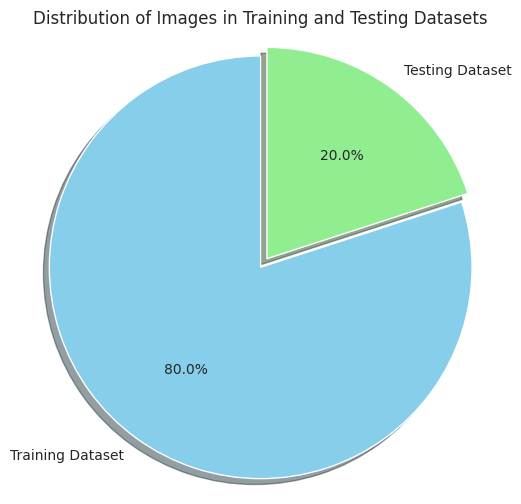

Training images: 11200
Testing images: 2801


In [ ]:
import os
import matplotlib.pyplot as plt

# Set your paths
TRAIN_ROOT = "/content/drive/MyDrive/Thesis/2. Kidney CT/Train"
TEST_ROOT = "/content/drive/MyDrive/Thesis/2. Kidney CT/Test"

# Allowed image extensions
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}

def count_images(folder_path):
    count = 0
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            # Skip hidden files and count only valid images
            if not file.startswith('.') and os.path.splitext(file.lower())[1] in image_extensions:
                count += 1
    return count

# Count images
training_images = count_images(TRAIN_ROOT)
testing_images = count_images(TEST_ROOT)

# Labels and data for pie chart
labels = ['Training Dataset', 'Testing Dataset']
data = [training_images, testing_images]
colors = ['skyblue', 'lightgreen']

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    data,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    shadow=True,
    explode=(0.05, 0)
)
plt.title('Distribution of Images in Training and Testing Datasets')
plt.axis('equal')
plt.show()

# Print image counts for reference
print(f"Training images: {training_images}")
print(f"Testing images: {testing_images}")

# Define data transformations and FL with 3 Clients

In [ ]:
import torch
from torch.utils.data import DataLoader, random_split, Subset
import torchvision.datasets as datasets
from torchvision import transforms
import numpy as np
from collections import defaultdict
import random

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Define data transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load full training dataset
full_train_dataset = datasets.ImageFolder(root=TRAIN_ROOT, transform=transform)

# Number of clients
NUM_CLIENTS = 3

# Function for balanced split (non-IID)
def create_balanced_split(dataset, num_clients):
    class_indices = defaultdict(list)

    # ✅ Use dataset.samples directly (path, label) without loading images
    for idx, (path, label) in enumerate(dataset.samples):
        class_indices[label].append(idx)

    # Shuffle class-wise
    for label in class_indices:
        random.shuffle(class_indices[label])

    # Split into clients
    client_datasets = [[] for _ in range(num_clients)]

    for label, indices in class_indices.items():
        num_samples_per_client = len(indices) // num_clients

        for i in range(num_clients):
            client_datasets[i].extend(indices[i * num_samples_per_client:(i + 1) * num_samples_per_client])

    return [Subset(dataset, indices) for indices in client_datasets]

# Create balanced splits
client_datasets = create_balanced_split(full_train_dataset, NUM_CLIENTS)

# Check if the datasets have been split correctly
for i, dataset in enumerate(client_datasets):
    print(f"Client {i+1} has {len(dataset)} samples.")

Client 1 has 3732 samples.
Client 2 has 3732 samples.
Client 3 has 3732 samples.


Non-IID Splitting

In [ ]:
test_dataset = datasets.ImageFolder(root=TEST_ROOT, transform=transform)

print("Number of images in full training dataset:", len(full_train_dataset))
for i, ds in enumerate(client_datasets):
    print(f"Client {i+1} dataset size:", len(ds))

print("Number of images in testing dataset:", len(test_dataset))

Number of images in full training dataset: 11200
Client 1 dataset size: 3732
Client 2 dataset size: 3732
Client 3 dataset size: 3732
Number of images in testing dataset: 2800


#Visualizing Training, Testing, and Client Datasets with Correct Labels (4×4 Grid)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Proper unnormalize
def unnormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(img_tensor.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(img_tensor.device)
    img_tensor = img_tensor * std + mean
    return img_tensor

# Correct 4x4 visualization with correct labels
def show_images_grid_with_labels(dataset, class_names, batch_size=16):
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    images, labels = next(iter(dataloader))

    images = images.cpu()
    labels = labels.cpu()

    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    axes = axes.flatten()

    for img, label, ax in zip(images, labels, axes):
        img = unnormalize(img)  # Unnormalize correctly
        npimg = img.numpy()
        npimg = np.transpose(npimg, (1, 2, 0))
        npimg = np.clip(npimg, 0, 1)

        ax.imshow(npimg)
        ax.set_title(class_names[label.item()], fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# ✅ Now call it correctly

# For full training dataset
print("🔍 Showing full training set:")
show_images_grid_with_labels(full_train_dataset, class_names)

# For testing dataset
print("🔍 Showing testing set:")
show_images_grid_with_labels(test_dataset, class_names)

# For each client
for i, client_ds in enumerate(client_datasets):
    print(f"\n🔍 Visualizing Client {i+1}'s dataset:")
    show_images_grid_with_labels(client_ds, class_names)

Output hidden; open in https://colab.research.google.com to view.

#Quick 2×2 Visualization of Training and Testing Datasets with Labels

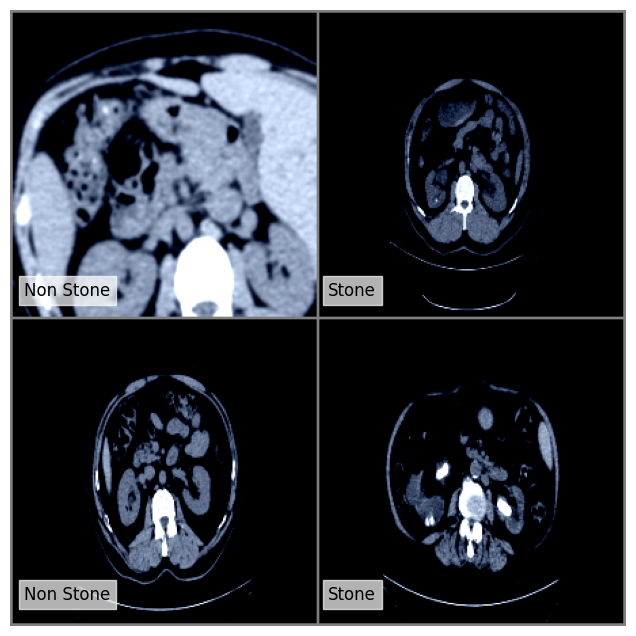

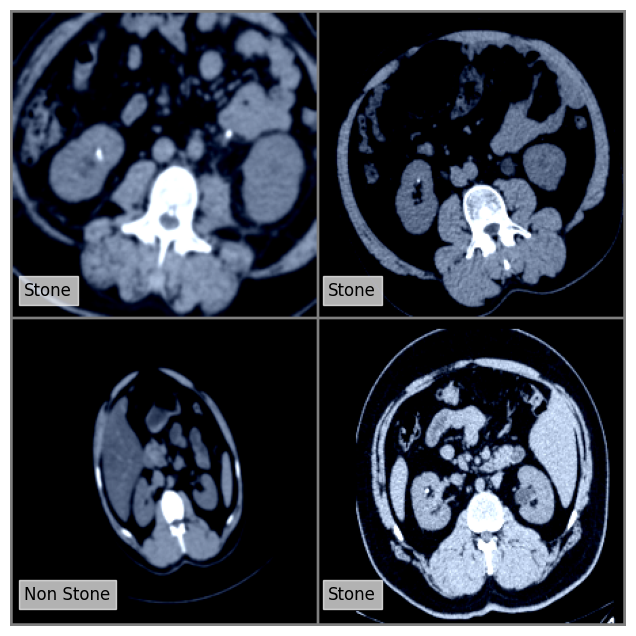

In [ ]:
# Function to show images with labels
def imshow_with_labels(imgs, labels, class_names):
    imgs = imgs / 2 + 0.5  # unnormalize
    npimg = imgs.numpy()
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(np.transpose(npimg, (1, 2, 0)))
    ax.axis('off')

    # Annotate each image with its corresponding label
    for i in range(4):
        row = i // 2
        col = i % 2
        ax.text(
            col * 224 + 10,  # x position
            row * 224 + 210, # y position (near the bottom of the image)
            class_names[labels[i]],
            bbox=dict(facecolor='white', alpha=0.7),
            fontsize=12, color='black'
        )
    plt.show()

# Display 2x2 images from a dataset with labels
def show_images_grid_with_labels(dataset, class_names):
    # Create a DataLoader
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=True)
    # Get a batch of images
    images, labels = next(iter(dataloader))

    # Display images with labels
    imshow_with_labels(torchvision.utils.make_grid(images, nrow=2), labels, class_names)

# Show 2x2 images from training data
show_images_grid_with_labels(full_train_dataset, class_names)

# Show 2x2 images from testing data
show_images_grid_with_labels(test_dataset, class_names)


# Create DataLoaders for Federated Clients

In [ ]:
from torch.utils.data import DataLoader

# Check if client_datasets is empty
if len(client_datasets) == 0:
    print("Error: client_datasets is empty. Please check your dataset splitting.")
else:
    # Create individual dataloaders for each client
    client_loaders = [
        DataLoader(ds, batch_size=16, shuffle=True) for ds in client_datasets
    ]

    # Optionally, print the number of dataloaders created
    print(f"Created {len(client_loaders)} client dataloaders.")

Created 3 client dataloaders.


#Load Pre-trained ResNet-8 Large_Weights Model

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

# Load ResNet18-Large with pretrained weights
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# Adjust the classifier for 4 classes (banana ripeness classification)

model.fc = torch.nn.Linear(model.fc.in_features, len(class_names))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


# Setup DataLoaders for Federated Clients and Global Testing

In [ ]:
batch_size = 32  # You can adjust based on local machine GPU memory

# Create DataLoaders for each client (use client_datasets from Non-IID split)
client_loaders = [
    torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,  # Safer on your machine (adjust based on performance)
        pin_memory=True  # Only needed if using a CUDA GPU, set to False for MPS or CPU
    )
    for dataset in client_datasets
]

# Keep test_loader as-is (for global evaluation after each round)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True  # Adjust this for your hardware (e.g., MPS or CPU)
)

# Create a train_loader for full global training evaluation if needed
train_loader = torch.utils.data.DataLoader(
    full_train_dataset,  # full training dataset
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True  # Adjust this based on your system (e.g., MPS or CPU)
)

# Load and Adjust RestNet-18-Large Model

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

# Load ResNet-18 with pretrained weights
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# Adjust the classifier for the correct number of output classes
model.fc = torch.nn.Linear(model.fc.in_features, len(class_names))

# Move the model to the device (GPU, MPS, or CPU)
model = model.to(device)

# DO NOT call model.eval() yet! (keep it in training mode)

# Federated Evaluation and Metrics Logging

In [ ]:
import os
import csv
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
import torch

# Define where you want to save the log file
metrics_log_path = "/content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/federated_metrics_log.csv"

# Create log file with headers (if it doesn't exist)
if not os.path.exists(metrics_log_path):
    with open(metrics_log_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Round", "Client", "Accuracy", "Precision", "Recall", "F1-Score"])

# Federated evaluation function
def federated_evaluation(model, dataloader, device, class_names, round_num, client_name):
    y_true = []
    y_pred = []

    model.eval()  # Set model to evaluation mode
    with torch.no_grad():  # Disable gradient calculation
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)  # Get the class predictions
            y_true.extend(labels.cpu().numpy())  # Store true labels
            y_pred.extend(preds.cpu().numpy())  # Store predicted labels

    # Calculate evaluation metrics
    acc = np.mean(np.array(y_true) == np.array(y_pred))  # Accuracy
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)  # Precision
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)  # Recall
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)  # F1-Score

    # Log to CSV file after each round
    with open(metrics_log_path, mode='a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([round_num, client_name, acc, prec, rec, f1])

    return acc, prec, rec, f1

# Federated Learning Training Loop and Model Evaluation

Using device: cuda

🔁 Federated Round 1/8
  🚀 Client 1 training...
     🧠 Client 1 (client-side) using AdamW optimizer.
     🧪 Client 1 - Train Acc: 50.05%, Test Acc: 48.86%
  🚀 Client 2 training...
     🧠 Client 2 (client-side) using SGD optimizer.
     🧪 Client 2 - Train Acc: 50.25%, Test Acc: 47.79%
  🚀 Client 3 training...
     🧠 Client 3 (client-side) using RMSprop optimizer.
     🧪 Client 3 - Train Acc: 49.65%, Test Acc: 50.20%
     🖥️ Server (server-side) performed FedAvg aggregation.
✅ Round 1 - Global Train Acc: 56.93% | Global Test Acc: 56.96%

🔁 Federated Round 2/8
  🚀 Client 1 training...
     🧠 Client 1 (client-side) using AdamW optimizer.
     🧪 Client 1 - Train Acc: 56.52%, Test Acc: 59.04%
  🚀 Client 2 training...
     🧠 Client 2 (client-side) using SGD optimizer.
     🧪 Client 2 - Train Acc: 56.82%, Test Acc: 57.70%
  🚀 Client 3 training...
     🧠 Client 3 (client-side) using RMSprop optimizer.
     🧪 Client 3 - Train Acc: 56.82%, Test Acc: 56.63%
     🖥️ Server (serve

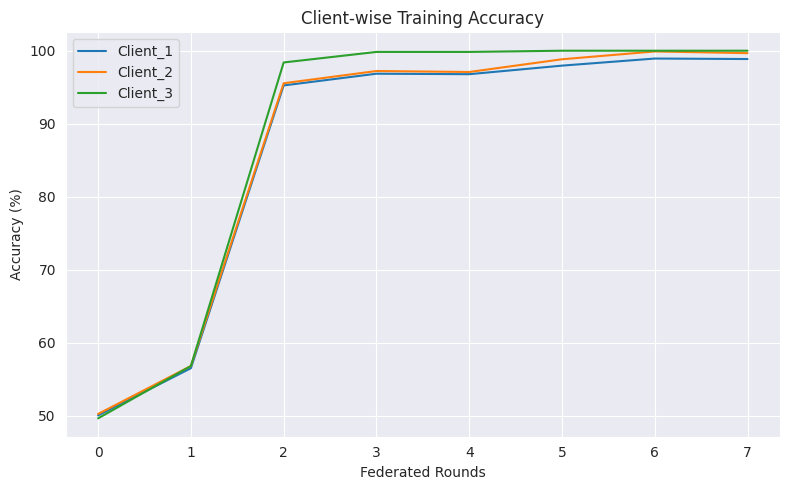

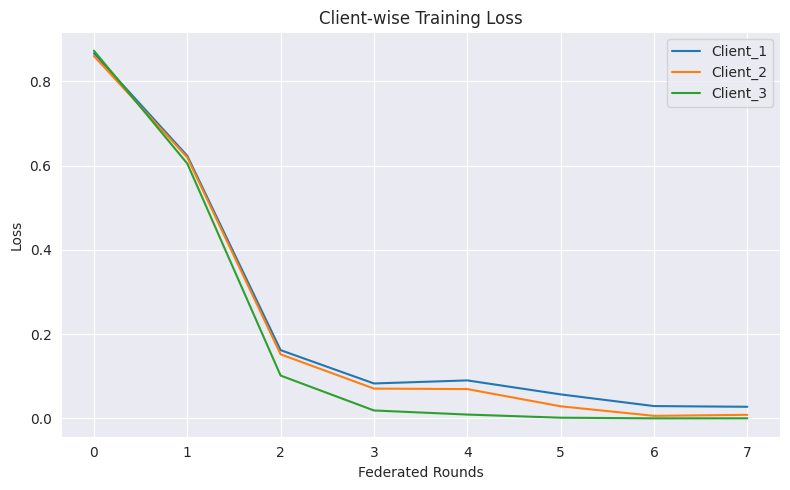

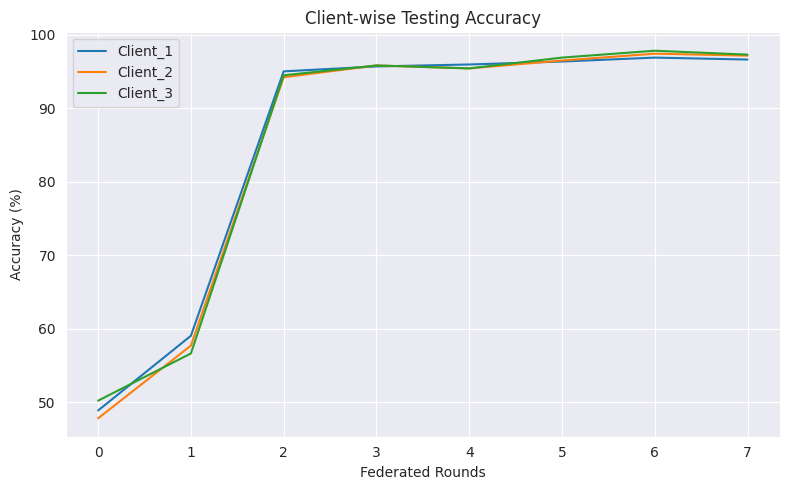

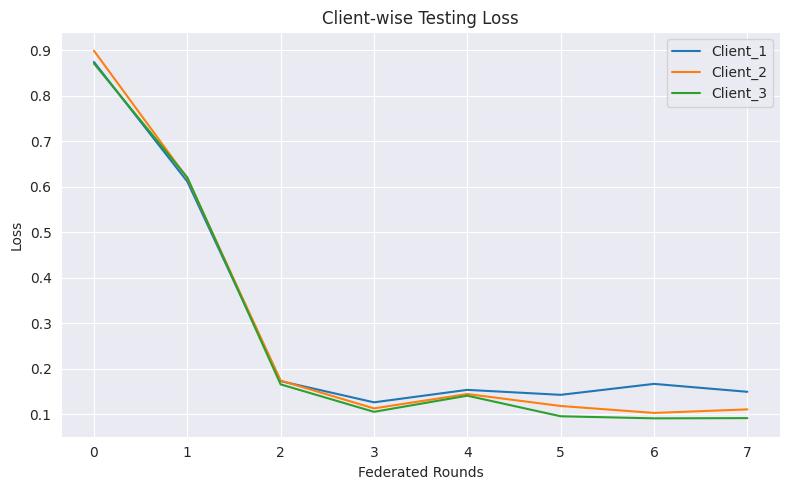

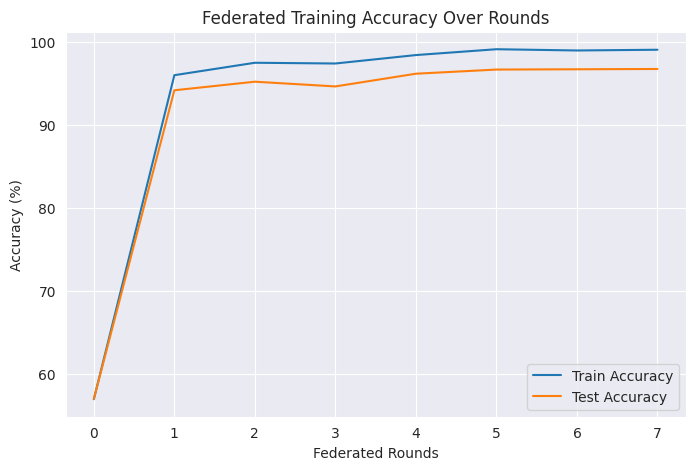

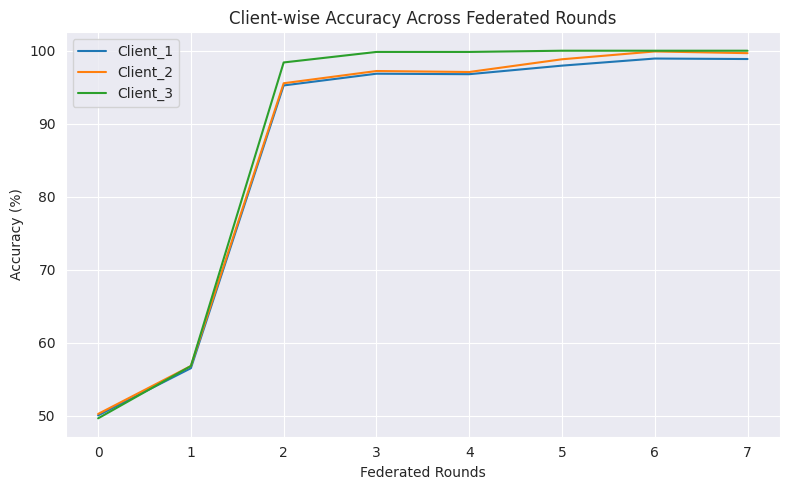

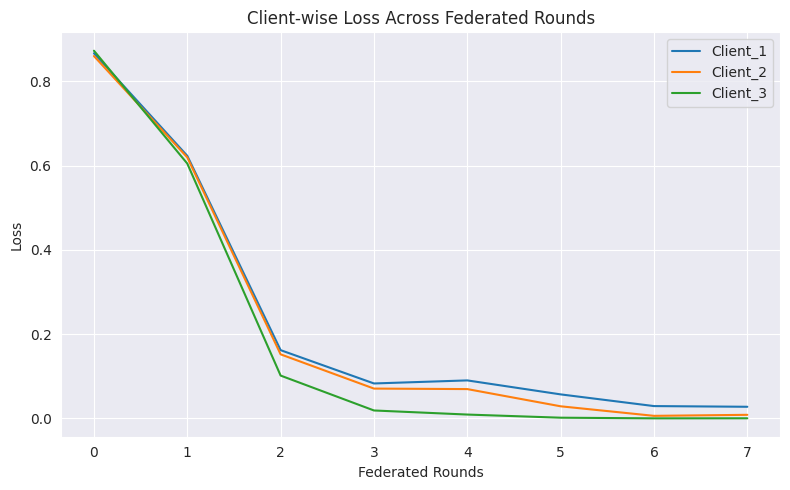

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet18, ResNet18_Weights # Corrected import
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy
import os # Import os for directory creation

import pandas as pd
import matplotlib.pyplot as plt

# 📁 Set output paths in your Google Drive project folder
base_path = "/content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/"

# Create the base directory if it doesn't exist
os.makedirs(base_path, exist_ok=True)


# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load MobileNetV3-Large with pretrained weights
weights = ResNet18_Weights.DEFAULT # Corrected weights
global_model = resnet18(weights=weights) # Corrected model

# Modify the classifier for 3 output classes
global_model.fc = nn.Linear(global_model.fc.in_features, len(class_names)) # Corrected classifier modification
global_model = global_model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Freeze all layers except the final classifier layer
for param in global_model.parameters():
    param.requires_grad = False
for param in global_model.fc.parameters(): # Corrected parameter access
    param.requires_grad = True

# Unfreeze the last 3 layers in the feature extractor
# ResNet18 structure is different, need to adjust this part based on ResNet18 architecture
# Let's unfreeze the last two blocks instead, which is more typical for fine-tuning ResNet
# The layers are typically in blocks. For ResNet18, features are in layers 1-4
# We can unfreeze layer4 and layer3
for param in global_model.layer4.parameters():
    param.requires_grad = True
for param in global_model.layer3.parameters():
    param.requires_grad = True


# Trackers
global_train_accuracies, global_test_accuracies = [], []

# Function to train a local model on client data with client-specific optimizer
def train_local_model(model, client_dataset, client_id, round_num, epochs=1):
    model = deepcopy(model)
    model.train()

    if client_id == 0:
        optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)
    elif client_id == 1:
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    elif client_id == 2:
        optimizer = optim.RMSprop(model.parameters(), lr=0.0005, alpha=0.99)
    else:
        optimizer = optim.Adam(model.parameters(), lr=0.0001)

    # 🔍 Log which optimizer this client is using
    if isinstance(optimizer, optim.AdamW):
        optimizer_name = "AdamW"
    elif isinstance(optimizer, optim.SGD):
        optimizer_name = "SGD"
    elif isinstance(optimizer, optim.RMSprop):
        optimizer_name = "RMSprop"
    elif isinstance(optimizer, optim.Adam):
        optimizer_name = "Adam"
    else:
        optimizer_name = "Unknown"

    print(f"     🧠 Client {client_id+1} (client-side) using {optimizer_name} optimizer.")

    # Save optimizer info to CSV
    with open(optimizer_log_path, mode='a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([round_num + 1, client_id + 1, optimizer_name, "client-side"])

    loader = DataLoader(client_dataset, batch_size=32, shuffle=True)

    for _ in range(epochs):
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    return model.state_dict()

# Function to average weights across all clients
def average_weights(state_dicts):
    avg_dict = deepcopy(state_dicts[0])
    for key in avg_dict.keys():
        for i in range(1, len(state_dicts)):
            avg_dict[key] += state_dicts[i][key]
        avg_dict[key] = avg_dict[key] / len(state_dicts)
    return avg_dict

# Function to calculate accuracy
def calculate_accuracy(loader, model, device):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    average_loss = running_loss / len(loader)
    model.train()
    return accuracy, average_loss

import csv

optimizer_log_path = base_path + "client_optimizer_log.csv"

# Create CSV file with headers if not already exists
with open(optimizer_log_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Round", "Client", "Optimizer", "Role"])

fedavg_log_path = base_path + "client_server_roles_log.csv"  # <--- ADD THIS

# Setup FedAvg log file before training
with open(fedavg_log_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Round", "Actor", "Action", "Role"])

global_accuracy_log_path = base_path + "global_accuracy_log.csv"

# Create the file with headers
with open(global_accuracy_log_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Round", "Global Train Accuracy (%)", "Global Test Accuracy (%)"])

# Federated Learning Training Loop
num_rounds = 8
local_epochs = 8

# -----------------------------
# ✅ Split each client's dataset into 80% train, 20% test
# -----------------------------
from torch.utils.data import random_split

client_train_datasets = []
client_test_datasets = []

for dataset in client_datasets:
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_subset, test_subset = random_split(dataset, [train_size, test_size])
    client_train_datasets.append(train_subset)
    client_test_datasets.append(test_subset)

# -----------------------------
# ✅ Initialize tracking matrices
# -----------------------------
client_accuracy_matrix = [[] for _ in range(NUM_CLIENTS)]
client_loss_matrix = [[] for _ in range(NUM_CLIENTS)]
client_test_accuracy_matrix = [[] for _ in range(NUM_CLIENTS)]
client_test_loss_matrix = [[] for _ in range(NUM_CLIENTS)]
global_train_accuracies, global_test_accuracies = [], []

# -----------------------------
# ✅ Setup optimizer log CSV
# -----------------------------
optimizer_log_path = base_path + "client_optimizer_log.csv"
import csv
with open(optimizer_log_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Round", "Client", "Optimizer", "Role"])

# -----------------------------
# 🔁 Federated Learning Training Loop
# -----------------------------
for round in range(num_rounds):
    print(f"\n🔁 Federated Round {round + 1}/{num_rounds}")
    client_states = []

    for i in range(NUM_CLIENTS):
        print(f"  🚀 Client {i+1} training...")
        train_data = client_train_datasets[i]
        test_data = client_test_datasets[i]

        local_state = train_local_model(global_model, train_data, client_id=i, round_num=round, epochs=local_epochs)
        client_states.append(local_state)

        # Evaluate on client training data
        train_loader = DataLoader(train_data, batch_size=32, shuffle=False)
        acc, loss = calculate_accuracy(train_loader, global_model, device)
        client_accuracy_matrix[i].append(acc)
        client_loss_matrix[i].append(loss)

        # Evaluate on client testing data
        test_loader = DataLoader(test_data, batch_size=32, shuffle=False)
        test_acc, test_loss = calculate_accuracy(test_loader, global_model, device)
        client_test_accuracy_matrix[i].append(test_acc)
        client_test_loss_matrix[i].append(test_loss)

        print(f"     🧪 Client {i+1} - Train Acc: {acc:.2f}%, Test Acc: {test_acc:.2f}%")

    # Federated Averaging
    global_model.load_state_dict(average_weights(client_states))
    print(f"     🖥️ Server (server-side) performed FedAvg aggregation.")

    # Log FedAvg action to CSV
    with open(fedavg_log_path, mode='a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([round + 1, "Server", "FedAvg aggregation performed", "server-side"])

    # Global Evaluation
    train_acc, _ = calculate_accuracy(DataLoader(full_train_dataset, batch_size=32), global_model, device)
    test_acc, _ = calculate_accuracy(DataLoader(test_dataset, batch_size=32), global_model, device)

    global_train_accuracies.append(train_acc)
    global_test_accuracies.append(test_acc)

    # Save to CSV
    with open(global_accuracy_log_path, mode='a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([round + 1, f"{train_acc:.2f}", f"{test_acc:.2f}"])

    print(f"✅ Round {round + 1} - Global Train Acc: {train_acc:.2f}% | Global Test Acc: {test_acc:.2f}%")

# -----------------------------
# 💾 Save all client-side matrices as CSV
# -----------------------------
acc_df = pd.DataFrame(client_accuracy_matrix).T
acc_df.columns = [f"Client_{i+1}" for i in range(NUM_CLIENTS)]
acc_df.to_csv(base_path + "client_accuracy_matrix.csv", index_label="Round")

loss_df = pd.DataFrame(client_loss_matrix).T
loss_df.columns = [f"Client_{i+1}" for i in range(NUM_CLIENTS)]
loss_df.to_csv(base_path + "client_loss_matrix.csv", index_label="Round")

test_acc_df = pd.DataFrame(client_test_accuracy_matrix).T
test_acc_df.columns = [f"Client_{i+1}" for i in range(NUM_CLIENTS)]
test_acc_df.to_csv(base_path + "client_test_accuracy_matrix.csv", index_label="Round")

test_loss_df = pd.DataFrame(client_test_loss_matrix).T
test_loss_df.columns = [f"Client_{i+1}" for i in range(NUM_CLIENTS)]
test_loss_df.to_csv(base_path + "client_test_loss_matrix.csv", index_label="Round")

# -----------------------------
# 📈 Plot: Per-client Accuracy & Loss (Train + Test)
# -----------------------------
def plot_metric_matrix(df, title, ylabel, filename):
    plt.figure(figsize=(8, 5))
    for col in df.columns:
        plt.plot(df.index, df[col], label=col)
    plt.title(title)
    plt.xlabel("Federated Rounds")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(base_path + filename)
    plt.show()

plot_metric_matrix(acc_df, "Client-wise Training Accuracy", "Accuracy (%)", "client_accuracy_plot.png")
plot_metric_matrix(loss_df, "Client-wise Training Loss", "Loss", "client_loss_plot.png")
plot_metric_matrix(test_acc_df, "Client-wise Testing Accuracy", "Accuracy (%)", "client_test_accuracy_plot.png")
plot_metric_matrix(test_loss_df, "Client-wise Testing Loss", "Loss", "client_test_loss_plot.png")

# -----------------------------
# 📊 Compute and Save Average Performance
# -----------------------------
avg_df = pd.DataFrame({
    "Train Accuracy (%)": acc_df.mean(),
    "Train Loss": loss_df.mean(),
    "Test Accuracy (%)": test_acc_df.mean(),
    "Test Loss": test_loss_df.mean()
})
avg_df.to_csv(base_path + "client_avg_performance_table.csv")


# Plot accuracy trend
plt.figure(figsize=(8, 5))
plt.plot(global_train_accuracies, label='Train Accuracy')
plt.plot(global_test_accuracies, label='Test Accuracy')
plt.title('Federated Training Accuracy Over Rounds')
plt.xlabel('Federated Rounds')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()


# -----------------------------
# 🔄 Post-training analysis block (Client-wise logging & export)
# -----------------------------


accuracy_csv_path = base_path + "client_accuracy_matrix.csv"
loss_csv_path = base_path + "client_loss_matrix.csv"
accuracy_plot_path = base_path + "client_accuracy_plot.png"
loss_plot_path = base_path + "client_loss_plot.png"
avg_csv_path = base_path + "client_avg_performance_table.csv"
avg_latex_path = base_path + "client_avg_performance_table.tex"


# 🔢 Convert client-wise accuracy/loss matrices to pandas DataFrames
acc_df = pd.DataFrame(client_accuracy_matrix).T
acc_df.columns = [f"Client_{i+1}" for i in range(NUM_CLIENTS)]

loss_df = pd.DataFrame(client_loss_matrix).T
loss_df.columns = [f"Client_{i+1}" for i in range(NUM_CLIENTS)]

# 💾 Save accuracy and loss matrices as CSV
acc_df.to_csv(accuracy_csv_path, index_label="Round")
loss_df.to_csv(loss_csv_path, index_label="Round")

# 📈 Plot: Per-client accuracy across rounds
plt.figure(figsize=(8, 5))
for col in acc_df.columns:
    plt.plot(acc_df.index, acc_df[col], label=col)
plt.title("Client-wise Accuracy Across Federated Rounds")
plt.xlabel("Federated Rounds")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(accuracy_plot_path)
plt.show()

# 📉 Plot: Per-client loss across rounds
plt.figure(figsize=(8, 5))
for col in loss_df.columns:
    plt.plot(loss_df.index, loss_df[col], label=col)
plt.title("Client-wise Loss Across Federated Rounds")
plt.xlabel("Federated Rounds")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(loss_plot_path)
plt.show()

# 📊 Compute and save average performance
avg_acc = acc_df.mean()
avg_loss = loss_df.mean()
avg_df = pd.DataFrame({"Avg Accuracy (%)": avg_acc, "Avg Loss": avg_loss})

# 💾 Save averages
avg_df.to_csv(avg_csv_path)

with open(avg_latex_path, "w") as f:
    f.write(avg_df.to_latex(index=True, float_format="%.2f"))

#Model Saving Path

In [ ]:
import torch
import os # Import os

# ✅ Save the trained global_model (after federated learning)

# Define the path to save inside Banana folder
# Define the path to save inside Banana folder
save_path = "/content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/Fmodel_resnet-18_trained.pth"

# Create the directory if it doesn't exist
os.makedirs(base_path, exist_ok=True)


# Create a simple dummy optimizer (only needed to save optimizer state)
optimizer = torch.optim.Adam(global_model.parameters(), lr=0.001)

# Save function
def save_model(model, optimizer, path):
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, path)
    print(f"✅ Trained model saved successfully to: {path}") # Explicitly print the save path

# Call save
save_model(global_model, optimizer, save_path)

✅ Trained model saved successfully to: /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/Fmodel_resnet-18_trained.pth


#Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import os
import pandas as pd

# Define class names
# class_names = ['UnRipe', 'Ripe', 'OverRipe', 'Rotten']

# Directory to save plots
os.makedirs(base_path + "confusion_matrices", exist_ok=True)

# Function to calculate confusion matrix (already exists)
def calculate_confusion_matrix(loader, model, device):
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 🛠 Force all 4 classes in matrix
    return confusion_matrix(all_labels, all_preds, labels=[0, 1,])

# Function to plot and save confusion matrix
def plot_confusion_matrix(cm, class_names, title, filename):
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(filename)
    print(f"✅ Saved confusion matrix: {filename}")
    plt.close()

# 🔁 Generate confusion matrices for all clients
for i in range(NUM_CLIENTS):
    client_name = f"Client_{i+1}"

    print(f"\n📊 Generating confusion matrices for {client_name}...")

    # Train set
    train_loader = DataLoader(client_train_datasets[i], batch_size=32, shuffle=False)
    cm_train = calculate_confusion_matrix(train_loader, global_model, device)
    train_path = f"{base_path}confusion_matrices/{client_name}_train_cm.png"
    plot_confusion_matrix(cm_train, class_names,
                          title=f"{client_name} - Train Confusion Matrix",
                          filename=train_path)

    # Test set
    test_loader = DataLoader(client_test_datasets[i], batch_size=32, shuffle=False)
    cm_test = calculate_confusion_matrix(test_loader, global_model, device)
    test_path = f"{base_path}confusion_matrices/{client_name}_test_cm.png"
    plot_confusion_matrix(cm_test, class_names,
                          title=f"{client_name} - Test Confusion Matrix",
                          filename=test_path)

# ✅ Now OUTSIDE the loop
print("\n📊 Generating confusion matrix for Global Server Model...")
# 🛠 Define server_test_loader properly
server_test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
cm_server = calculate_confusion_matrix(server_test_loader, global_model, device)
server_path = f"{base_path}confusion_matrices/Server_Global_Test_cm.png"
plot_confusion_matrix(cm_server, class_names,
                      title="Server Global Model - Test Confusion Matrix",
                      filename=server_path)

# Save as CSV too (optional)
pd.DataFrame(cm_server).to_csv(f"{base_path}confusion_matrices/Server_Global_Test_cm.csv", index=False)
print(f"✅ Saved Server Confusion Matrix CSV as well.")


📊 Generating confusion matrices for Client_1...
✅ Saved confusion matrix: /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/confusion_matrices/Client_1_train_cm.png
✅ Saved confusion matrix: /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/confusion_matrices/Client_1_test_cm.png

📊 Generating confusion matrices for Client_2...
✅ Saved confusion matrix: /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/confusion_matrices/Client_2_train_cm.png
✅ Saved confusion matrix: /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/confusion_matrices/Client_2_test_cm.png

📊 Generating confusion matrices for Client_3...
✅ Saved confusion matrix: /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/confusion_matrices/Client_3_train_cm.png
✅ Saved confusion matrix: /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/confusion_matrices/Client_3_test_cm.png

📊 Generating confusion matrix for Global Server Model...
✅ Saved confusion matrix: /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18

#ROC Curve Generation for Server and Clients

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Prepare server-side full test loader
server_test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Make sure the directory for ROC plots exists
os.makedirs(base_path + "roc_curves", exist_ok=True)

# ✅ Binarize the labels (for ROC curve)
num_classes = len(class_names)

# Function to plot ROC curve
def plot_roc_curve(loader, model, device, class_names, title, filename):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())

    all_probs = torch.cat(all_probs, dim=0).numpy()
    all_labels = torch.cat(all_labels, dim=0).numpy()

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # Handle binary classification separately
    if num_classes == 2:
        # For binary classification, roc_curve expects the true labels and the probability of the positive class
        # The true labels for roc_curve should be 1D (0 or 1)
        fpr[1], tpr[1], _ = roc_curve(all_labels, all_probs[:, 1])
        roc_auc[1] = auc(fpr[1], tpr[1])

        # Plot ROC curve for the positive class
        plt.figure(figsize=(8, 6))
        plt.plot(fpr[1], tpr[1], label=f"{class_names[1]} (AUC = {roc_auc[1]:.2f})")

    else: # Handle multi-class classification
        all_labels_bin = label_binarize(all_labels, classes=list(range(num_classes)))
        for i in range(num_classes):
            fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        # Plot ROC curve for each class
        plt.figure(figsize=(8, 6))
        for i in range(num_classes):
            plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

    plt.plot([0, 1], [0, 1], 'k--', label='Chance')
    plt.title(title)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(filename)
    print(f"✅ Saved ROC curve plot: {filename}")
    plt.close()

# ✅ Now generate ROC curve for the Global Server Model
print("\n📈 Generating ROC Curve for Global Server Model...")
plot_roc_curve(server_test_loader, global_model, device, class_names,
               title="Global Server Model ROC Curve",
               filename=f"{base_path}roc_curves/global_server_roc_curve.png")

# 🔁 Generate ROC curves for each client
for i in range(NUM_CLIENTS):
    client_name = f"Client_{i+1}"
    print(f"\n📈 Generating ROC Curve for {client_name}...")

    client_test_loader = DataLoader(client_test_datasets[i], batch_size=32, shuffle=False)
    plot_roc_curve(client_test_loader, global_model, device, class_names,
                   title=f"{client_name} - ROC Curve",
                   filename=f"{base_path}roc_curves/{client_name}_roc_curve.png")


📈 Generating ROC Curve for Global Server Model...
✅ Saved ROC curve plot: /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/roc_curves/global_server_roc_curve.png

📈 Generating ROC Curve for Client_1...
✅ Saved ROC curve plot: /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/roc_curves/Client_1_roc_curve.png

📈 Generating ROC Curve for Client_2...
✅ Saved ROC curve plot: /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/roc_curves/Client_2_roc_curve.png

📈 Generating ROC Curve for Client_3...
✅ Saved ROC curve plot: /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/roc_curves/Client_3_roc_curve.png


#AUC

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import torch
from torch.utils.data import DataLoader

# Use all_labels and all_probs from the previous cell
# Binarize the true labels for AUC calculation
# Regenerate all_labels and all_probs within this cell's scope
all_labels = []
all_probs = []

global_model.eval() # Set model to evaluation mode
with torch.no_grad():
    for inputs, labels in test_loader: # Use the pre-defined test_loader
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = global_model(inputs)
        probs = torch.softmax(outputs, dim=1) # Get probabilities

        all_probs.append(probs.cpu())
        all_labels.append(labels.cpu())

all_probs = torch.cat(all_probs, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

n_classes = len(class_names) # Define n_classes within this cell


y_true_bin_auc = label_binarize(all_labels, classes=list(range(n_classes)))

auc_scores = {}
if n_classes == 2:
    # For binary classification, roc_auc_score expects the probability of the positive class
    auc_scores[class_names[1]] = roc_auc_score(y_true_bin_auc, all_probs[:, 1])
else:
    for i in range(n_classes):
        auc_scores[class_names[i]] = roc_auc_score(y_true_bin_auc[:, i], all_probs[:, i])

for class_name, auc_score in auc_scores.items():
    print(f"AUC for class {class_name}: {auc_score:.2f}")

if n_classes > 2:
    micro_auc = roc_auc_score(y_true_bin_auc, all_probs, average="micro")
    print(f"Micro-average AUC: {micro_auc:.2f}")

    macro_auc = roc_auc_score(y_true_bin_auc, all_probs, average="macro")
    print(f"Macro-average AUC: {macro_auc:.2f}")

AUC for class Stone: 1.00


#Precision Recall Curve

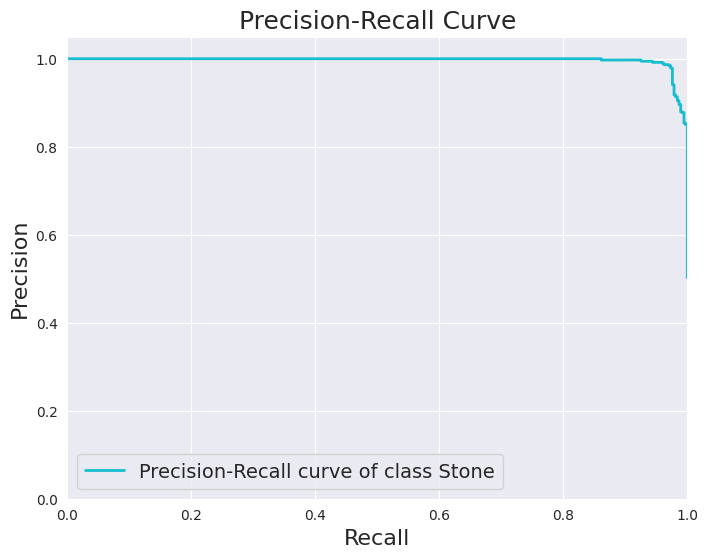

AUC for class Stone: 1.00


In [ ]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import label_binarize
import torch
from torch.utils.data import DataLoader

# Get predictions and true labels from the PyTorch test_loader
all_labels = []
all_probs = []

global_model.eval() # Set model to evaluation mode
with torch.no_grad():
    for inputs, labels in test_loader: # Use the pre-defined test_loader
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = global_model(inputs)
        probs = torch.softmax(outputs, dim=1) # Get probabilities

        all_probs.append(probs.cpu())
        all_labels.append(labels.cpu())

all_probs = torch.cat(all_probs, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

n_classes = len(class_names)

# Binarize the true labels for precision-recall curve calculation
if n_classes == 2:
    y_true_for_pr = all_labels  # Use original 1D labels for binary
    all_probs_for_pr = all_probs[:, 1] # Use probabilities of the positive class
else:
    y_true_bin = label_binarize(all_labels, classes=list(range(n_classes)))
    y_true_for_pr = y_true_bin # Use binarized labels for multi-class
    all_probs_for_pr = all_probs # Use all probabilities for multi-class


colors = plt.cm.get_cmap('tab10', n_classes).colors

precision = dict()
recall = dict()

plt.figure(figsize=(8, 6))

if n_classes == 2:
    precision[1], recall[1], _ = precision_recall_curve(y_true_for_pr, all_probs_for_pr)
    plt.plot(recall[1], precision[1], color=colors[1], lw=2,
             label=f'Precision-Recall curve of class {class_names[1]}') # Plot for the positive class
else:
    for i, color in zip(range(n_classes), colors):
        precision[i], recall[i], _ = precision_recall_curve(y_true_for_pr[:, i], all_probs_for_pr[:, i])
        plt.plot(recall[i], precision[i], color=color, lw=2,
                 label=f'Precision-Recall curve of class {class_names[i]}') # Use class_names here


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=16)
plt.ylabel('Precision', fontsize=16)
plt.title('Precision-Recall Curve', fontsize=18)
plt.legend(loc="lower left", fontsize=14)
plt.savefig(base_path + 'PR_Curve.png', dpi=300) # Save to drive
plt.show()

# AUC calculation (can reuse the code from the previous cell if needed, but for completeness)
auc_scores = {}
y_true_bin_auc = label_binarize(all_labels, classes=list(range(n_classes)))

if n_classes == 2:
    auc_scores[class_names[1]] = roc_auc_score(y_true_bin_auc, all_probs[:, 1])
else:
    for i in range(n_classes):
        auc_scores[class_names[i]] = roc_auc_score(y_true_bin_auc[:, i], all_probs[:, i])

for class_name, auc_score in auc_scores.items():
    print(f"AUC for class {class_name}: {auc_score:.2f}")

if n_classes > 2:
    micro_auc = roc_auc_score(y_true_bin_auc, all_probs, average="micro")
    print(f"Micro-average AUC: {micro_auc:.2f}")

    macro_auc = roc_auc_score(y_true_bin_auc, all_probs, average="macro")
    print(f"Macro-average AUC: {macro_auc:.2f}")

#LIME

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=98f4cca1904ad7caedd884a89bec6f1f6af3a0cc9dec04cf8883d0bc85c14880
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import lime
import lime.lime_image
import torch
from torchvision.models import resnet18, ResNet18_Weights # Corrected import
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
from skimage.segmentation import mark_boundaries # Import mark_boundaries

# Define the path to the saved PyTorch model
# Define the path to save inside Banana folder
base_path = "/content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/"
save_path = os.path.join(base_path, "Fmodel_resnet-18_trained.pth")

# ✅ Check if the model file exists
if not os.path.exists(save_path):
    print(f"Error: Model file not found at {save_path}")
else:
    print(f"✅ Model file found at {save_path}. Proceeding to load.")
    # Load the trained PyTorch model
    # Need to recreate the model architecture before loading the state dict
    weights = ResNet18_Weights.DEFAULT # Corrected weights
    model = resnet18(weights=weights) # Corrected model
    # Adjust the classifier for 2 output classes (assuming binary classification based on class_names)
    model.fc = torch.nn.Linear(model.fc.in_features, len(class_names)) # Corrected classifier modification

    # Load the saved state dictionary
    checkpoint = torch.load(save_path, map_location=device) # Load the entire dictionary
    model.load_state_dict(checkpoint['model_state_dict']) # Load only the model's state dict

    model = model.to(device)
    model.eval() # Set model to evaluation mode

    # Define the image transformation used during training
    transform = transforms.Compose([
        transforms.Resize((224, 224)), # LIME might work better with the original training size or smaller for faster computation
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Function to preprocess images for LIME (expects numpy array, returns numpy array of probabilities)
    def pytorch_predict_fn(images):
        # LIME passes images as numpy arrays, often not normalized initially.
        # We need to preprocess each image individually.
        processed_images = torch.stack([transform(Image.fromarray(img.astype('uint8'), 'RGB')) for img in images])
        processed_images = processed_images.to(device)
        with torch.no_grad():
            outputs = model(processed_images)
        # Get probabilities
        probs = torch.softmax(outputs, dim=1)
        return probs.cpu().numpy()


    explainer = lime.lime_image.LimeImageExplainer()

    # List of paths to the images you want to explain
    img_paths = [
       r"/content/drive/MyDrive/Thesis/2. Kidney CT/Test/Stone 7000/augmented_5613.jpg",
       r"/content/drive/MyDrive/Thesis/2. Kidney CT/Test/Non Stone 7000/augmented_466.jpg",# Using a test image that was used successfully in Grad-CAM
    ]

    # Create directory to save LIME explanations
    lime_save_dir = os.path.join(base_path, "lime_explanations")
    os.makedirs(lime_save_dir, exist_ok=True)


    # Iterate through the image paths and generate explanations
    for img_path in img_paths:
        # ✅ Check if the image file exists
        if not os.path.exists(img_path):
            print(f"Error: Image file not found at {img_path}. Skipping.")
            continue # Skip to the next image if the file is not found

        print(f"Generating LIME explanation for: {img_path}")
        img_pil = Image.open(img_path).convert('RGB')
        img_np = np.array(img_pil) # LIME expects numpy array

        # Explanation for the top predicted class
        # LIME explainer.explain_instance expects the original image (numpy array)
        explanation = explainer.explain_instance(img_np,
                                                 pytorch_predict_fn,
                                                 top_labels=len(class_names),
                                                 hide_color=0,
                                                 num_samples=1000) # You might need to adjust num_samples

        # Get image and mask for the top predicted class
        temp, mask = explanation.get_image_and_mask(explanation.top_labels[0],
                                                    positive_only=True,
                                                    num_features=5, # Number of features (superpixels) to include
                                                    hide_rest=False) # Set to True to hide everything but the features

        # Display the LIME explanation
        plt.figure(figsize=(8, 8))
        # Mark boundaries expects normalized image (0-1 range)
        plt.imshow(mark_boundaries(temp / 255.0, mask)) # Assuming temp is 0-255
        plt.axis('off')
        plt.title(f"LIME Explanation for class: {class_names[explanation.top_labels[0]]}")

        # Save the LIME explanation image
        img_filename = os.path.basename(img_path)
        save_filename = f"LIME_{os.path.splitext(img_filename)[0]}.png"
        save_path = os.path.join(lime_save_dir, save_filename)

        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Saved LIME Explanation to: {save_path}")
        plt.close() # Close the plot to free up memory

✅ Model file found at /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/Fmodel_resnet-18_trained.pth. Proceeding to load.
Generating LIME explanation for: /content/drive/MyDrive/Thesis/2. Kidney CT/Test/Stone 7000/augmented_5613.jpg


  0%|          | 0/1000 [00:00<?, ?it/s]

✅ Saved LIME Explanation to: /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/lime_explanations/LIME_augmented_5613.png
Generating LIME explanation for: /content/drive/MyDrive/Thesis/2. Kidney CT/Test/Non Stone 7000/augmented_466.jpg


  0%|          | 0/1000 [00:00<?, ?it/s]

✅ Saved LIME Explanation to: /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/lime_explanations/LIME_augmented_466.png


#SHAP

✅ Model file found at /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/Fmodel_resnet-18_trained.pth. Proceeding to load.
Generating SHAP explanation for: /content/drive/MyDrive/Thesis/2. Kidney CT/Test/Stone 7000/augmented_5613.jpg


  0%|          | 0/7998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:34, 34.18s/it]               


✅ Saved SHAP Explanation to: /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/shap_explanations/SHAP_augmented_5613.png
Generating SHAP explanation for: /content/drive/MyDrive/Thesis/2. Kidney CT/Test/Non Stone 7000/augmented_466.jpg


  0%|          | 0/7998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:45, 45.34s/it]               


✅ Saved SHAP Explanation to: /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/shap_explanations/SHAP_augmented_466.png


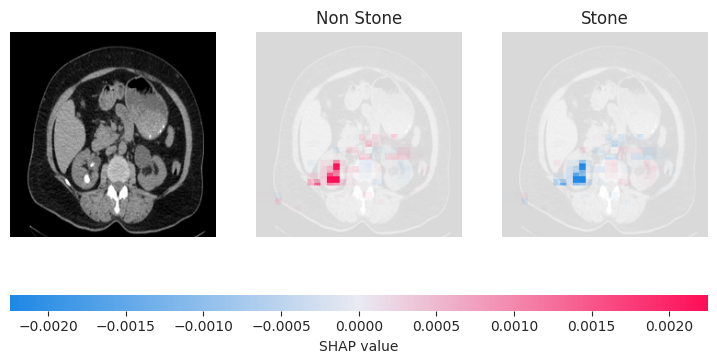

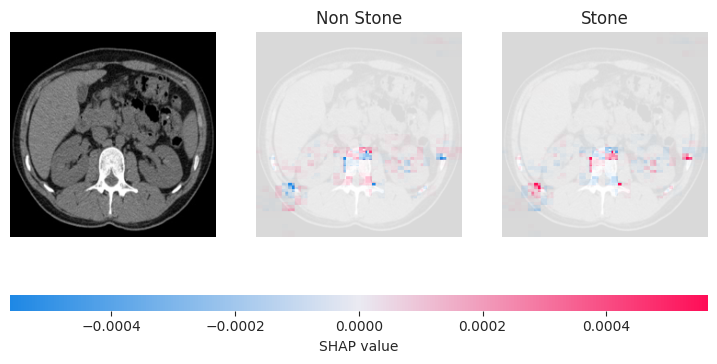

In [ ]:
import os
import numpy as np
import torch
import shap
from PIL import Image
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights # Corrected imports
import matplotlib.pyplot as plt

# Define the path to the saved PyTorch model
# Define the path to save inside Banana folder
base_path = "/content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/"
save_path = os.path.join(base_path, "Fmodel_resnet-18_trained.pth")

# Load the trained PyTorch model
# Need to recreate the model architecture before loading the state dict
weights = ResNet18_Weights.DEFAULT # Corrected weights
model = resnet18(weights=weights) # Corrected model
# Adjust the classifier for 4 output classes (assuming class_names is defined)
model.fc = torch.nn.Linear(model.fc.in_features, len(class_names)) # Corrected classifier modification

# Load the saved state dictionary
if not os.path.exists(save_path):
    print(f"Error: Model file not found at {save_path}")
else:
    print(f"✅ Model file found at {save_path}. Proceeding to load.")
    if torch.cuda.is_available():
        device = torch.device("cuda")
        checkpoint = torch.load(save_path)
    else:
        device = torch.device("cpu")
        checkpoint = torch.load(save_path, map_location=device)

    model.load_state_dict(checkpoint['model_state_dict'])

    model = model.to(device)
    model.eval() # Set model to evaluation mode


# Define the image transformation used during training
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# List of paths to the images you want to explain
img_paths = [
   r"/content/drive/MyDrive/Thesis/2. Kidney CT/Test/Stone 7000/augmented_5613.jpg",
   r"/content/drive/MyDrive/Thesis/2. Kidney CT/Test/Non Stone 7000/augmented_466.jpg",# Using a test image that was used successfully in Grad-CAM
]

# Create directory to save SHAP explanations
shap_save_dir = os.path.join(base_path, "shap_explanations")
os.makedirs(shap_save_dir, exist_ok=True)

def preprocess_image_shap(image_path):
    """
    Preprocesses a single image for SHAP explanation with a PyTorch model.
    Returns a numpy array ready for the prediction function.
    """
    img_pil = Image.open(image_path).convert('RGB')
    img_pil = img_pil.resize((224, 224)) # Resize to model input size
    img_np = np.array(img_pil) # SHAP's masker often expects numpy
    return img_np


# Prediction function for SHAP (expects numpy array, returns numpy array of probabilities)
# SHAP will pass different masked versions of the image as numpy arrays.
def pytorch_predict_fn_shap(images_np):
    """
    Prediction function wrapper for SHAP explainer with a PyTorch model.
    Converts numpy images to tensors, runs inference, and returns probabilities as numpy.
    """
    # Need to handle single image or batch of images passed by SHAP
    if images_np.ndim == 3: # Single image (H, W, C)
        images_np = images_np[np.newaxis, ...] # Add batch dimension
    elif images_np.ndim == 5: # Batch of images (N, 1, H, W, C) - common with masker
         images_np = images_np.squeeze(1) # Remove extra dimension

    # Apply the same transformations as during training to each image
    # This requires looping through the batch of numpy images
    processed_images = torch.stack([transform(Image.fromarray(img.astype('uint8'), 'RGB')) for img in images_np])

    processed_images = processed_images.to(device)

    with torch.no_grad():
        model.eval() # Ensure model is in evaluation mode
        outputs = model(processed_images)

    # Get probabilities and return as numpy array
    probs = torch.softmax(outputs, dim=1)
    return probs.cpu().numpy()


# Iterate through the image paths and generate SHAP explanations for each
for img_path in img_paths:
    # ✅ Check if the image file exists
    if not os.path.exists(img_path):
        print(f"Error: Image file not found at {img_path}. Skipping SHAP analysis for this image.")
        continue # Skip to the next image if the file is not found

    print(f"Generating SHAP explanation for: {img_path}")
    img_np = preprocess_image_shap(img_path)

    # Define the masker for images
    # Use the preprocessed image shape (H, W, C)
    masker_blur = shap.maskers.Image("blur(100,100)", shape=(img_np.shape[0], img_np.shape[1], img_np.shape[2]))

    # Create the explainer
    # Pass the prediction function and the masker
    explainer_blur = shap.Explainer(pytorch_predict_fn_shap, masker_blur)

    # Generate SHAP values
    # The explainer expects the original image (numpy array)
    # outputs=shap.Explanation.argsort.flip[:len(class_names)] gets values for top predicted classes
    # Increase max_evals for potentially better accuracy, but it takes longer
    shap_values_fine = explainer_blur(img_np[np.newaxis, :, :, :], max_evals=8000, outputs=shap.Explanation.argsort.flip[:len(class_names)])


    # Visualize and save the SHAP values
    fig = plt.figure(figsize=(10, 10))
    shap.image_plot(shap_values_fine, show=False, labels=class_names) # Add labels for clarity
    # Save the plot
    img_filename = os.path.basename(img_path)
    save_filename = f"SHAP_{os.path.splitext(img_filename)[0]}.png"
    save_path = os.path.join(shap_save_dir, save_filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Saved SHAP Explanation to: {save_path}")
    plt.close(fig) # Close the figure to free up memory

# Grand CAM

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
from torchvision.models import resnet18, ResNet18_Weights # Corrected imports
from torchvision import transforms
from PIL import Image
import os # Import os to handle file paths

# Define the path to the saved PyTorch model
# Define the path to save inside Banana folder
base_path = "/content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/"
save_path = os.path.join(base_path, "Fmodel_resnet-18_trained.pth")


# Load the trained PyTorch model
# Need to recreate the model architecture before loading the state dict
weights = ResNet18_Weights.DEFAULT # Corrected weights
model = resnet18(weights=weights) # Corrected model
# Adjust the classifier for the correct number of output classes (assuming class_names is defined)
model.fc = torch.nn.Linear(model.fc.in_features, len(class_names)) # Corrected classifier modification


# Load the saved state dictionary
if not os.path.exists(save_path):
    print(f"Error: Model file not found at {save_path}")
else:
    print(f"✅ Model file found at {save_path}. Proceeding to load.")
    if torch.cuda.is_available():
        device = torch.device("cuda")
        checkpoint = torch.load(save_path)
    else:
        device = torch.device("cpu")
        checkpoint = torch.load(save_path, map_location=device)

    model.load_state_dict(checkpoint['model_state_dict'])

    model = model.to(device)
    model.eval() # Set model to evaluation mode


# Define the image transformation used during training
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize to the input size expected by the model
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# List of paths to the images you want to explain
img_paths = [
   r"/content/drive/MyDrive/Thesis/2. Kidney CT/Test/Stone 7000/augmented_5613.jpg",
   r"/content/drive/MyDrive/Thesis/2. Kidney CT/Test/Non Stone 7000/augmented_466.jpg",# Using a test image that was used successfully in Grad-CAM
]


# Get the last convolutional layer
# For ResNet18, a common layer to use for Grad-CAM is 'layer4'
last_conv_layer = model.layer4[-1] # Use the last convolutional layer in layer4


# Create directory to save Grad-CAM visualizations
gradcam_save_dir = os.path.join(base_path, "gradcam_visualizations")
os.makedirs(gradcam_save_dir, exist_ok=True)

# Define save_gradients and save_activations outside the loop
gradients = None
activations = None

def save_gradients(grad):
    global gradients
    gradients = grad

def save_activations(module, input, output):
    global activations
    activations = output


# Iterate through the image paths and generate Grad-CAM visualization for each
for img_path in img_paths:
    # ✅ Check if the image file exists
    if not os.path.exists(img_path):
        print(f"Error: Image file not found at {img_path}. Skipping Grad-CAM for this image.")
        continue # Skip to the next image if the file is not found

    print(f"Generating Grad-CAM visualization for: {img_path}")

    img_pil = Image.open(img_path).convert('RGB')
    img_tensor = transform(img_pil).unsqueeze(0).to(device) # Add batch dim and move to device

    # Get the original image as numpy for overlay
    img_np_original = np.array(img_pil)

    # Ensure model is in training mode and requires gradients for the relevant parts
    model.train()
    img_tensor.requires_grad_(True)

    # Register forward hook to capture activations
    hook_activations = last_conv_layer.register_forward_hook(save_activations)

    # Perform a forward pass to get the predictions and activations
    with torch.enable_grad():
        outputs = model(img_tensor)

    # Remove forward hook after getting activations
    hook_activations.remove()

    # Get the predicted class index from the outputs where gradients were calculated
    _, predicted_class_idx = torch.max(outputs, 1)
    target_class_idx = predicted_class_idx.item()

    # Get the score for the predicted class
    score = outputs[0, target_class_idx]

    # Register hook for gradients during backward pass directly on the activations tensor
    # This hook must be registered AFTER the forward pass that generated 'activations'
    # and BEFORE the backward pass that computes gradients.
    hook_gradients = activations.register_hook(save_gradients)

    # Perform a backward pass on the scalar score to compute the gradients
    model.zero_grad() # Zero gradients before backward pass
    score.backward() # Compute gradients

    # Remove backward hook
    hook_gradients.remove()

    # Get the gradients and the activations
    pooled_gradients = torch.mean(gradients, dim=[0, 2, 3]) # Pool the gradients across spatial dimensions

    # Calculate the heatmap
    # Keep activations on the same device as pooled_gradients for multiplication
    activations = activations.squeeze(0) # Remove batch dim
    heatmap = activations * pooled_gradients.unsqueeze(-1).unsqueeze(-1) # Multiply each channel by its corresponding pooled gradient
    heatmap = torch.sum(heatmap, dim=0) # Sum across channels to get the final heatmap


    # Normalize the heatmap - Move to CPU for numpy conversion
    heatmap = np.maximum(heatmap.detach().cpu().numpy(), 0) # Apply ReLU and convert to numpy
    heatmap = heatmap / np.max(heatmap) if np.max(heatmap) > 0 else heatmap # Normalize


    # Resize and overlay the heatmap
    heatmap = cv2.resize(heatmap, (img_np_original.shape[1], img_np_original.shape[0])) # Resize to original image size
    heatmap = np.uint8(255 * heatmap)

    # Apply a colormap
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Superimpose the heatmap on the original image
    # Convert original image to BGR if it's RGB for OpenCV
    if img_np_original.shape[2] == 3:
        img_np_original_bgr = cv2.cvtColor(img_np_original, cv2.COLOR_RGB2BGR)
    else:
         img_np_original_bgr = cv2.cvtColor(img_np_original, cv2.COLOR_GRAY2BGR)


    superimposed_img = cv2.addWeighted(img_np_original_bgr, 0.6, heatmap, 0.4, 0)


    # Convert back to RGB for matplotlib
    superimposed_img_rgb = cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)


    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_np_original) # Display original image
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img_rgb) # Display superimposed image
    plt.title("Grad-CAM")
    plt.axis('off')

    plt.tight_layout()

    # Save the Grad-CAM visualization image
    img_filename = os.path.basename(img_path)
    save_filename = f"GradCAM_{os.path.splitext(img_filename)[0]}.png"
    save_path = os.path.join(gradcam_save_dir, save_filename)

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Saved Grad-CAM Visualization to: {save_path}")
    plt.close() # Close the plot to free up memory

✅ Model file found at /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/Fmodel_resnet-18_trained.pth. Proceeding to load.
Generating Grad-CAM visualization for: /content/drive/MyDrive/Thesis/2. Kidney CT/Test/Stone 7000/augmented_5613.jpg
✅ Saved Grad-CAM Visualization to: /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/gradcam_visualizations/GradCAM_augmented_5613.png
Generating Grad-CAM visualization for: /content/drive/MyDrive/Thesis/2. Kidney CT/Test/Non Stone 7000/augmented_466.jpg
✅ Saved Grad-CAM Visualization to: /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/gradcam_visualizations/GradCAM_augmented_466.png


#Occlusion Sensitivity

In [ ]:
import numpy as np

def occlude_image(image, patch, x, y):
    """
    Applies an occlusion patch to an image at a given position.

    Args:
        image (np.ndarray): The original image as a NumPy array.
        patch (np.ndarray): The occlusion patch as a NumPy array.
        x (int): The x-coordinate (column) for the top-left corner of the patch.
        y (int): The y-coordinate (row) for the top-left corner of the patch.

    Returns:
        np.ndarray: The image with the occlusion patch applied.
    """
    # Create a copy to avoid modifying the original image
    occluded_image = np.copy(image)

    # Determine patch dimensions
    patch_height, patch_width = patch.shape[:2]

    # Calculate the end coordinates for the patch, respecting image boundaries
    x_end = min(x + patch_width, occluded_image.shape[1])
    y_end = min(y + patch_height, occluded_image.shape[0])

    # Calculate the actual portion of the patch to use if near boundaries
    patch_x_end = x_end - x
    patch_y_end = y_end - y

    # Place the patch onto the image
    occluded_image[y:y_end, x:x_end] = patch[0:patch_y_end, 0:patch_x_end]

    return occluded_image

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
from torchvision.models import resnet18, ResNet18_Weights # Corrected imports
from torchvision import transforms
from PIL import Image
import os # Import os to handle file paths

# Define the path to the saved PyTorch model
# Define the path to save inside Banana folder
base_path = "/content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/"
save_path = os.path.join(base_path, "Fmodel_resnet-18_trained.pth")



# Load the trained PyTorch model
# Need to recreate the model architecture before loading the state dict
weights = ResNet18_Weights.DEFAULT # Corrected weights
model = resnet18(weights=weights) # Corrected model
# Adjust the classifier for the correct number of output classes (assuming class_names is defined)
model.fc = torch.nn.Linear(model.fc.in_features, len(class_names)) # Corrected classifier modification


# Load the saved state dictionary
if not os.path.exists(save_path): # Corrected: Use save_path
    print(f"Error: Model file not found at {save_path}") # Corrected: Use save_path
else:
    print(f"✅ Model file found at {save_path}. Proceeding to load.") # Corrected: Use save_path
    if torch.cuda.is_available():
        device = torch.device("cuda")
        checkpoint = torch.load(save_path) # Corrected: Use save_path
    else:
        device = torch.device("cpu")
        checkpoint = torch.load(save_path, map_location=device) # Corrected: Use save_path

    model.load_state_dict(checkpoint['model_state_dict']) # Load only the model's state dict

    model = model.to(device)
    model.eval() # Set model to evaluation mode

# Define the image transformation used during training
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize to the input size expected by the model
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 1. Define the size of the occlusion patch
patch_size = (20, 20) # 20x20 pixels

# 2. Create the occlusion patch (a gray square)
# Assuming the image is RGB (3 channels) and pixel values are 0-255
occlusion_patch = np.full((patch_size[0], patch_size[1], 3), 128, dtype=np.uint8) # Use a mid-gray color

# Define the step size for sliding the patch
step_size = 10 # 10 pixels

# List of paths to the images you want to explain
img_paths = [
   r"/content/drive/MyDrive/Thesis/2. Kidney CT/Test/Stone 7000/augmented_5613.jpg",
   r"/content/drive/MyDrive/Thesis/2. Kidney CT/Test/Non Stone 7000/augmented_466.jpg",# Using a test image that was used successfully in Grad-CAM
]


# Create directory to save Occlusion Sensitivity visualizations
occlusion_save_dir = os.path.join(base_path, "occlusion_sensitivity")
os.makedirs(occlusion_save_dir, exist_ok=True)


# Iterate through the image paths and generate occlusion sensitivity maps for each
for img_path in img_paths:
    # ✅ Check if the image file exists
    if not os.path.exists(img_path):
        print(f"Error: Image file not found at {img_path}. Skipping Occlusion Sensitivity for this image.")
        continue # Skip to the next image if the file is not found

    print(f"Generating Occlusion Sensitivity Map for: {img_path}")

    img_pil = Image.open(img_path).convert('RGB')
    original_image_np = np.array(img_pil) # Convert to numpy array

    # List to store occluded images
    occluded_images = []

    # 3. Iterate through the image with a defined step size
    img_height, img_width = original_image_np.shape[:2]
    patch_height, patch_width = occlusion_patch.shape[:2]

    for y in range(0, img_height - patch_height + 1, step_size):
        for x in range(0, img_width - patch_width + 1, step_size):
            # 4. Call the occlude_image function
            occluded_img = occlude_image(original_image_np, occlusion_patch, x, y)
            # 5. Store the generated occluded images
            occluded_images.append(occluded_img)

    print(f"Generated {len(occluded_images)} occluded images.")

    # Get the predicted class of the original image to use as the target class
    original_image_tensor = transform(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        original_outputs = model(original_image_tensor.to(device)) # Ensure model is on device here
        _, original_preds = torch.max(original_outputs, 1)
    target_class_idx = original_preds.item()

    # List to store the prediction probabilities for the target class
    prediction_probabilities = []

    # Iterate through the occluded images
    for occluded_img_np in occluded_images:
        # Convert NumPy array to PIL Image, apply transforms, add batch dim, and move to device
        occluded_img_pil = Image.fromarray(occluded_img_np.astype('uint8'), 'RGB')
        occluded_img_tensor = transform(occluded_img_pil).unsqueeze(0).to(device)

        # Get model predictions
        with torch.no_grad():
            outputs = model(occluded_img_tensor.to(device)) # Ensure model is on device here

        # Apply softmax to get probabilities
        probs = torch.softmax(outputs, dim=1)

        # Get the probability for the target class
        target_class_prob = probs[0, target_class_idx].item()

        # Append the probability to the list
        prediction_probabilities.append(target_class_prob)

    print(f"Obtained prediction probabilities for {len(prediction_probabilities)} occluded images.")

    # Calculate the sensitivity map
    # Sensitivity is the change in prediction probability for the target class
    # compared to the original prediction without occlusion.
    sensitivity_map = np.array(prediction_probabilities)

    # Reshape the sensitivity map into a 2D grid
    # Calculate grid dimensions based on original image size and step size
    grid_height = (img_height - patch_height) // step_size + 1
    grid_width = (img_width - patch_width) // step_size + 1

    sensitivity_map_reshaped = sensitivity_map.reshape(grid_height, grid_width)


    # 1. Resize the sensitivity map to the same dimensions as the original image.
    # The sensitivity_map_reshaped is already a numpy array
    sensitivity_map_resized = cv2.resize(sensitivity_map_reshaped, (original_image_np.shape[1], original_image_np.shape[0]), interpolation=cv2.INTER_LANCZOS4)


    # 2. Convert the sensitivity map to a format suitable for a heatmap visualization (e.g., uint8 and apply a colormap).
    # Normalize the resized map to 0-255
    sensitivity_map_normalized = np.uint8(255 * (sensitivity_map_resized - np.min(sensitivity_map_resized)) / (np.max(sensitivity_map_resized) - np.min(sensitivity_map_resized) + 1e-8)) # Add epsilon for stability

    # Apply a colormap
    heatmap = cv2.applyColorMap(sensitivity_map_normalized, cv2.COLORMAP_JET)

    # 3. Superimpose the colormapped sensitivity map onto the original image.
    # Convert original image to BGR if it's RGB for OpenCV
    if original_image_np.shape[2] == 3:
        original_image_bgr = cv2.cvtColor(original_image_np, cv2.COLOR_RGB2BGR)
    else:
         original_image_bgr = cv2.cvtColor(original_image_np, cv2.COLOR_GRAY2BGR)


    superimposed_img = cv2.addWeighted(original_image_bgr, 0.6, heatmap, 0.4, 0)

    # Convert back to RGB for matplotlib
    superimposed_img_rgb = cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)


    # 4. Display the original image and the superimposed image side-by-side using Matplotlib.
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original_image_np) # Display original image
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img_rgb) # Display superimposed image
    plt.title("Occlusion Sensitivity Map")
    plt.axis('off')

    plt.tight_layout()

    # 6. Save the resulting visualization to a file in the specified base_path.
    img_filename = os.path.basename(img_path)
    save_filename = f"OcclusionSensitivity_{os.path.splitext(img_filename)[0]}.png"
    save_path = os.path.join(occlusion_save_dir, save_filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Saved Occlusion Sensitivity Map visualization to: {save_path}")

    # 7. Close the plot to free up memory
    plt.close()

✅ Model file found at /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/Fmodel_resnet-18_trained.pth. Proceeding to load.
Generating Occlusion Sensitivity Map for: /content/drive/MyDrive/Thesis/2. Kidney CT/Test/Stone 7000/augmented_5613.jpg
Generated 576 occluded images.
Obtained prediction probabilities for 576 occluded images.
✅ Saved Occlusion Sensitivity Map visualization to: /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/occlusion_sensitivity/OcclusionSensitivity_augmented_5613.png
Generating Occlusion Sensitivity Map for: /content/drive/MyDrive/Thesis/2. Kidney CT/Test/Non Stone 7000/augmented_466.jpg
Generated 576 occluded images.
Obtained prediction probabilities for 576 occluded images.
✅ Saved Occlusion Sensitivity Map visualization to: /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/occlusion_sensitivity/OcclusionSensitivity_augmented_466.png


#integrated gradients

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os # Import os if not already imported in this cell
import torch
from torchvision import transforms
from PIL import Image
from torchvision.models import resnet18, ResNet18_Weights # Corrected imports


# Define the path to the saved PyTorch model
# Define the path to save inside Banana folder
base_path = "/content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/"
save_path = os.path.join(base_path, "Fmodel_resnet-18_trained.pth")


# Load the trained PyTorch model
# Need to recreate the model architecture before loading the state dict
weights = ResNet18_Weights.DEFAULT # Corrected weights
global_model = resnet18(weights=weights) # Corrected model
# Adjust the classifier for the correct number of output classes (assuming class_names is defined)
global_model.fc = torch.nn.Linear(global_model.fc.in_features, len(class_names)) # Corrected classifier modification


# Load the saved state dictionary
if not os.path.exists(save_path):
    print(f"Error: Model file not found at {save_path}")
else:
    print(f"✅ Model file found at {save_path}. Proceeding to load.")
    if torch.cuda.is_available():
        device = torch.device("cuda")
        checkpoint = torch.load(save_path)
    else:
        device = torch.device("cpu")
        checkpoint = torch.load(save_path, map_location=device)

    global_model.load_state_dict(checkpoint['model_state_dict']) # Load only the model's state dict

    global_model = global_model.to(device) # Ensure model is on device
    global_model.eval() # Set model to evaluation mode


# Define the image transformation used during training
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize to the input size expected by the model
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# Redefine calculate_integrated_gradients to pass the interpolated image directly
def calculate_integrated_gradients(model, original_image_tensor, baseline_image_tensor, target_class_idx, num_steps=50):
    """
    Calculates Integrated Gradients for a given image and target class.

    Args:
        model (torch.nn.Module): The PyTorch model.
        original_image_tensor (torch.Tensor): The original input image tensor [1, C, H, W].
        baseline_image_tensor (torch.Tensor): The baseline image tensor [1, C, H, W].
        target_class_idx (int): The index of the target class.
        num_steps (int): The number of interpolation steps.

    Returns:
        torch.Tensor: The integrated gradients.
    """
    # Ensure tensors are on the same device
    device = original_image_tensor.device
    baseline_image_tensor = baseline_image_tensor.to(device)

    # List to store gradients at each interpolation step
    interpolated_gradients = []

    # Iterate through interpolation steps
    for step in range(num_steps):
        # Calculate interpolated image (already has batch dim [1, C, H, W])
        alpha = step / num_steps
        interpolated_image = baseline_image_tensor + alpha * (original_image_tensor - baseline_image_tensor)

        # Calculate gradients at the current step
        # Pass the interpolated_image directly as it already has a batch dimension
        gradients = calculate_gradients(model, interpolated_image, target_class_idx)

        # Append gradients (remove batch dim before appending if calculate_gradients returns batched gradients)
        # Check the shape returned by calculate_gradients and squeeze accordingly
        if gradients.ndim == 4: # Assuming calculate_gradients returns [1, C, H, W]
             interpolated_gradients.append(gradients.squeeze(0))
        else: # Assuming calculate_gradients returns [C, H, W]
             interpolated_gradients.append(gradients)


    # Average the gradients across all steps
    avg_gradients = torch.mean(torch.stack(interpolated_gradients), dim=0)

    # Calculate integrated gradients
    # The difference should be calculated between the original and baseline tensors *before*
    # averaging the gradients across channels for visualization.
    # Integrated gradients should have the same shape as the input image [C, H, W] or [1, C, H, W] if batched.
    # Let's assume original_image_tensor and baseline_image_tensor are [1, C, H, W]
    integrated_gradients = avg_gradients * (original_image_tensor.squeeze(0) - baseline_image_tensor.squeeze(0))


    return integrated_gradients

# Define calculate_gradients function
def calculate_gradients(model, image_tensor, target_class_idx):
    """
    Calculates the gradients of the target class score with respect to the input image tensor.

    Args:
        model (torch.nn.Module): The PyTorch model.
        image_tensor (torch.Tensor): The input image tensor [1, C, H, W].
        target_class_idx (int): The index of the target class.

    Returns:
        torch.Tensor: The gradients of the target class score with respect to the input tensor.
    """
    # Ensure the input tensor requires gradients
    image_tensor.requires_grad_(True)

    # Perform forward pass
    outputs = model(image_tensor)

    # Get the score for the target class
    score = outputs[0, target_class_idx]

    # Zero gradients
    model.zero_grad()

    # Perform backward pass to compute gradients
    score.backward()

    # Return the gradients with respect to the input tensor
    return image_tensor.grad


# List of paths to the images you want to explain
img_paths = [
   r"/content/drive/MyDrive/Thesis/2. Kidney CT/Test/Stone 7000/augmented_5613.jpg",
   r"/content/drive/MyDrive/Thesis/2. Kidney CT/Test/Non Stone 7000/augmented_466.jpg",# Using a test image that was used successfully in Grad-CAM
]


# Create directory to save Integrated Gradients visualizations
ig_save_dir = os.path.join(base_path, "integrated_gradients")
os.makedirs(ig_save_dir, exist_ok=True)


# Iterate through the image paths and generate Integrated Gradients visualizations for each
for img_path in img_paths:
    # ✅ Check if the image file exists
    if not os.path.exists(img_path):
        print(f"Error: Image file not found at {img_path}. Skipping Integrated Gradients for this image.")
        continue # Skip to the next image if the file is not found

    print(f"Generating Integrated Gradients visualization for: {img_path}")

    img_pil = Image.open(img_path).convert('RGB')
    original_image_np = np.array(img_pil) # Convert to numpy array

    # Preprocess the original image and move to device
    original_image_tensor = transform(img_pil).unsqueeze(0).to(device)

    # Create a baseline image (e.g., a black image) and preprocess it
    baseline_image_np = np.zeros_like(original_image_np)
    baseline_image_pil = Image.fromarray(baseline_image_np.astype('uint8'), 'RGB')
    baseline_image_tensor = transform(baseline_image_pil).unsqueeze(0).to(device)

    # Get the predicted class of the original image to use as the target class
    with torch.no_grad():
        outputs = global_model(original_image_tensor)
        _, original_preds = torch.max(outputs, 1)
    predicted_class_idx = original_preds.item()


    # Instead of just the predicted class, run IG for all classes
    num_classes = len(class_names)  # Make sure class_names is defined

    # Iterate over all classes
    for class_idx in range(num_classes):
        # Calculate Integrated Gradients for this class
        integrated_gradients = calculate_integrated_gradients(
            model=global_model,
            original_image_tensor=original_image_tensor,
            baseline_image_tensor=baseline_image_tensor,
            target_class_idx=class_idx,
            num_steps=50
        )

        # Normalize IG for visualization
        integrated_gradients_normalized = torch.abs(integrated_gradients).sum(dim=0, keepdim=True)
        integrated_gradients_normalized = (integrated_gradients_normalized - integrated_gradients_normalized.min()) / \
                                          (integrated_gradients_normalized.max() - integrated_gradients_normalized.min() + 1e-8)

        integrated_gradients_np = integrated_gradients_normalized.squeeze(0).cpu().numpy()
        integrated_gradients_resized = cv2.resize(integrated_gradients_np, (original_image_np.shape[1], original_image_np.shape[0]))
        integrated_gradients_uint8 = np.uint8(255 * integrated_gradients_resized)
        heatmap = cv2.applyColorMap(integrated_gradients_uint8, cv2.COLORMAP_JET)

        # Blend with original image
        if original_image_np.shape[2] == 3:
            original_image_bgr = cv2.cvtColor(original_image_np, cv2.COLOR_RGB2BGR)
        else:
            original_image_bgr = cv2.cvtColor(original_image_np, cv2.COLOR_GRAY2BGR)

        superimposed_img = cv2.addWeighted(original_image_bgr, 0.6, heatmap, 0.4, 0)
        superimposed_img_rgb = cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)

        # Plot and save
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(original_image_np)
        plt.title("Original Image")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(superimposed_img_rgb)
        plt.title(f"Integrated Gradients (Target: {class_names[class_idx]})")
        plt.axis('off')

        plt.tight_layout()

        # Save with class-specific filename
        img_filename_base = os.path.splitext(os.path.basename(img_path))[0]
        save_path = os.path.join(ig_save_dir, f"integrated_gradients_{img_filename_base}_{class_names[class_idx]}.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
        print(f"✅ Saved IG visualization for {img_filename_base}, class {class_names[class_idx]} to: {save_path}")

✅ Model file found at /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/Fmodel_resnet-18_trained.pth. Proceeding to load.
Generating Integrated Gradients visualization for: /content/drive/MyDrive/Thesis/2. Kidney CT/Test/Stone 7000/augmented_5613.jpg
✅ Saved IG visualization for augmented_5613, class Non Stone to: /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/integrated_gradients/integrated_gradients_augmented_5613_Non Stone.png
✅ Saved IG visualization for augmented_5613, class Stone to: /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/integrated_gradients/integrated_gradients_augmented_5613_Stone.png
Generating Integrated Gradients visualization for: /content/drive/MyDrive/Thesis/2. Kidney CT/Test/Non Stone 7000/augmented_466.jpg
✅ Saved IG visualization for augmented_466, class Non Stone to: /content/drive/MyDrive/Thesis/2. Kidney CT/ResNet-18/integrated_gradients/integrated_gradients_augmented_466_Non Stone.png
✅ Saved IG visualization for augmented_466, class Stone t

#MISE DATA

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data (federated rounds)
rounds = np.arange(0, 8)

# Sample accuracy data for 3 clients
accuracy_client1 = [45, 98, 99, 99, 99, 99, 99, 99]
accuracy_client2 = [46, 97, 98, 99, 99, 99, 99, 99]
accuracy_client3 = [44, 99, 100, 100, 100, 100, 100, 100]

# Sample loss data (scaled × 100) for 3 clients
loss_client1 = [100, 25, 10, 5, 3, 3, 3, 3]
loss_client2 = [100, 30, 12, 6, 4, 4, 4, 4]
loss_client3 = [100, 20, 8, 4, 2, 2, 2, 2]

# Create figure and subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# Plot settings for each subplot
clients = [
    ("Client_1", "AdamW", accuracy_client1, loss_client1),
    ("Client_2", "SGD with momentum", accuracy_client2, loss_client2),
    ("Client_3", "RMSprop", accuracy_client3, loss_client3)
]

for i, (client, optimizer, acc, loss) in enumerate(clients):
    ax = axes[i]
    ax2 = ax.twinx()

    # Plot accuracy (blue)
    ax.plot(rounds, acc, 'o-', color='blue', label="Accuracy (%)")
    ax.set_ylabel("Accuracy (%)", color='blue')
    ax.tick_params(axis='y', labelcolor='blue')

    # Plot loss (red)
    ax2.plot(rounds, loss, 's--', color='red', label="Loss (× 100)")
    ax2.set_ylabel("Loss (scaled × 100)", color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # Titles and labels
    ax.set_title(f"{client} Performance Across Federated Rounds\nOptimizer: {optimizer}")
    ax.set_xlabel("Federated Rounds")
    ax.set_xticks(rounds)

# Adjust layout
plt.tight_layout()
plt.show()

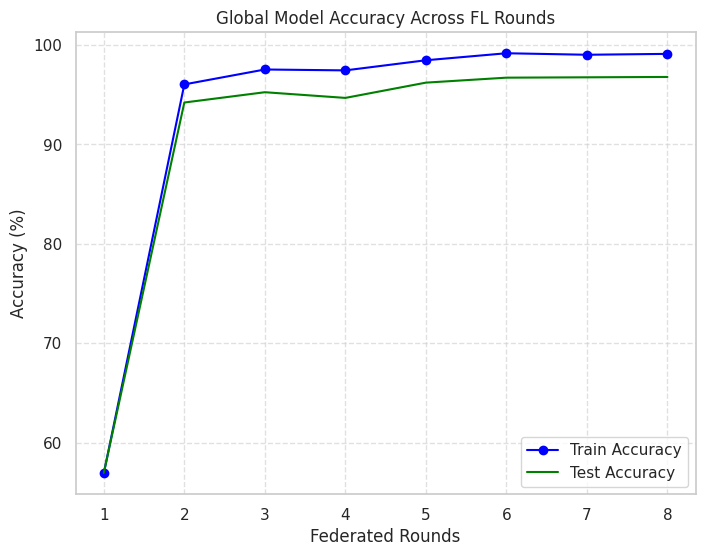

In [ ]:
import matplotlib.pyplot as plt

# Assuming global_train_accuracies and global_test_accuracies lists are available from the training cell
# If not, you would need to load them from a saved file or re-run the training.

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(global_train_accuracies) + 1), global_train_accuracies, 'o-', color='blue', label='Train Accuracy')
plt.plot(range(1, len(global_test_accuracies) + 1), global_test_accuracies, '-', color='green', label='Test Accuracy')

# Labels and title
plt.xlabel('Federated Rounds')
plt.ylabel('Accuracy (%)')
plt.title('Global Model Accuracy Across FL Rounds')

# Legend
plt.legend()

# Grid for readability
plt.grid(True, linestyle='--', alpha=0.6)

# Show plot
plt.show()

**Reasoning**:
Load a test image, preprocess it, and get the model's predicted class which will be used as the target class for Grad-CAM.



In [ ]:
import random
from PIL import Image
import numpy as np
import torch

# Select a random image path from the predefined list for demonstration
img_path = random.choice(img_paths)
print(f"Selected image for analysis: {img_path}")

# Load the image using PIL and preprocess it
img_pil = Image.open(img_path).convert('RGB')
img_tensor = transform(img_pil).unsqueeze(0).to(device) # Add batch dim and move to device

# Get the model's prediction for this single image
global_model.eval() # Set model to evaluation mode
with torch.no_grad():
    outputs = global_model(img_tensor)
    _, predicted_class_idx = torch.max(outputs, 1)
    predicted_class_idx = predicted_class_idx.item() # Get the scalar index

# Get the corresponding class name
predicted_class_name = class_names[predicted_class_idx]

print(f"Predicted class index: {predicted_class_idx}")
print(f"Predicted class name: {predicted_class_name}")

# The predicted_class_idx will be used as the target_class_idx for Grad-CAM
target_class_idx = predicted_class_idx

Selected image for analysis: /content/drive/MyDrive/Thesis/2. Kidney CT/Test/Non Stone 7000/augmented_466.jpg
Predicted class index: 0
Predicted class name: Non Stone


In [ ]:
# Ensure global_model, transform, device, class_names, img_path, and target_class_idx are accessible

# 2. Load the image and preprocess
img_pil = Image.open(img_path).convert('RGB')
# Keep original image numpy for later overlay
img_np_original = np.array(img_pil)

img_tensor = transform(img_pil).unsqueeze(0).to(device) # Add batch dim and move to device


# 3. Identify the last convolutional layer
# For ResNet18, a common layer to use for Grad-CAM is 'layer4'
last_conv_layer = global_model.layer4[-1] # Corrected: Access the last layer of layer4


# Define save_gradients and save_activations outside the loop
gradients = None
activations = None

# 4. & 5. Define hook functions
def save_gradients(grad):
    global gradients
    gradients = grad

def save_activations(module, input, output):
    global activations
    activations = output

# 6. Register the forward hook to the last convolutional layer
hook_activations = last_conv_layer.register_forward_hook(save_activations)

# 7. Perform a forward pass to get the predictions and activations
with torch.enable_grad(): # Enable gradients for the forward pass to get gradients later
    outputs = global_model(img_tensor)

# 8. Calculate the scalar score for the target_class_idx
score = outputs[0, target_class_idx]

# 9. Zero the gradients of the model
global_model.zero_grad()

# 10. Register hook for gradients during backward pass
hook_gradients = activations.register_hook(save_gradients)


# 11. Perform a backward pass on the scalar score to compute the gradients
score.backward() # Compute gradients

# 12. Remove hooks
hook_activations.remove()
hook_gradients.remove()

# 13. Compute the weighted average of the activations using the pooled gradients
pooled_gradients = torch.mean(gradients, dim=[0, 2, 3]) # Pool the gradients across spatial dimensions

# Keep activations on the same device as pooled_gradients for multiplication
activations = activations.squeeze(0) # Remove batch dim
heatmap = activations * pooled_gradients.unsqueeze(-1).unsqueeze(-1) # Multiply each channel by its corresponding pooled gradient
heatmap = torch.sum(heatmap, dim=0) # Sum across channels to get the final heatmap

# 14. Apply a ReLU activation to the weighted average to get the raw heatmap
# 15. Normalize the heatmap to a range of 0 to 1 - Move to CPU for numpy conversion
heatmap = np.maximum(heatmap.detach().cpu().numpy(), 0) # Apply ReLU and convert to numpy
heatmap = heatmap / np.max(heatmap) if np.max(heatmap) > 0 else heatmap # Normalize

# 16. Store the normalized heatmap for the next step (already stored in the 'heatmap' variable)
print("✅ Grad-CAM heatmap generated successfully.")

✅ Grad-CAM heatmap generated successfully.


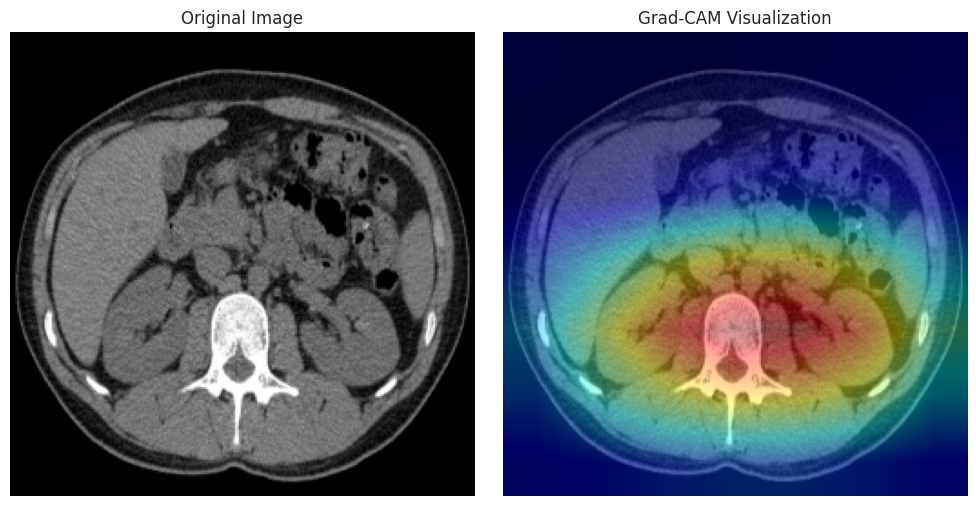

✅ Grad-CAM visualization displayed.


In [ ]:
# Resize and overlay the heatmap
# The heatmap needs to be resized to the original image dimensions
heatmap_resized = cv2.resize(heatmap, (img_np_original.shape[1], img_np_original.shape[0])) # Resize to original image size
heatmap_uint8 = np.uint8(255 * heatmap_resized) # Convert to uint8

# Apply a colormap
heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

# Superimpose the heatmap on the original image
# Convert original image to BGR if it's RGB for OpenCV
if img_np_original.shape[2] == 3:
    img_np_original_bgr = cv2.cvtColor(img_np_original, cv2.COLOR_RGB2BGR)
else:
     img_np_original_bgr = cv2.cvtColor(img_np_original, cv2.COLOR_GRAY2BGR)


# Blend the original image and the heatmap
superimposed_img = cv2.addWeighted(img_np_original_bgr, 0.6, heatmap_colored, 0.4, 0)

# Convert back to RGB for matplotlib display
superimposed_img_rgb = cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)

# Display the original image and the superimposed image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_np_original) # Display original image
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(superimposed_img_rgb) # Display superimposed image
plt.title("Grad-CAM Visualization")
plt.axis('off')

plt.tight_layout()
plt.show()

print("✅ Grad-CAM visualization displayed.")

In [ ]:
import random
from PIL import Image
import numpy as np
import torch

# Select a random image path from the predefined list for demonstration
img_path = random.choice(img_paths)
print(f"Selected image for analysis: {img_path}")

# Load the image using PIL and preprocess it
img_pil = Image.open(img_path).convert('RGB')
img_tensor = transform(img_pil).unsqueeze(0).to(device) # Add batch dim and move to device

# Get the model's prediction for this single image
global_model.eval() # Set model to evaluation mode
with torch.no_grad():
    outputs = global_model(img_tensor)
    _, predicted_class_idx = torch.max(outputs, 1)
    predicted_class_idx = predicted_class_idx.item() # Get the scalar index

# Get the corresponding class name
predicted_class_name = class_names[predicted_class_idx]

print(f"Predicted class index: {predicted_class_idx}")
print(f"Predicted class name: {predicted_class_name}")

# The predicted_class_idx will be used as the target_class_idx for Grad-CAM
target_class_idx = predicted_class_idx

Selected image for analysis: /content/drive/MyDrive/Thesis/2. Kidney CT/Test/Non Stone 7000/augmented_466.jpg
Predicted class index: 0
Predicted class name: Non Stone


In [ ]:
# Ensure global_model, transform, device, class_names, img_path, and target_class_idx are accessible

# 2. Load the image and preprocess
img_pil = Image.open(img_path).convert('RGB')
# Keep original image numpy for later overlay
img_np_original = np.array(img_pil)

img_tensor = transform(img_pil).unsqueeze(0).to(device) # Add batch dim and move to device


# 3. Identify the last convolutional layer
# For ResNet-18-Large, the last convolutional layer is typically the last layer in the 'features' sequential
last_conv_layer = global_model.layer4[-1] # Corrected to access ResNet layer4


# Define save_gradients and save_activations outside the loop
gradients = None
activations = None

# 4. & 5. Define hook functions
def save_gradients(grad):
    global gradients
    gradients = grad

def save_activations(module, input, output):
    global activations
    activations = output

# 6. Register the forward hook to the last convolutional layer
hook_activations = last_conv_layer.register_forward_hook(save_activations)

# 7. Perform a forward pass to get the predictions and activations
with torch.enable_grad(): # Enable gradients for the forward pass to get gradients later
    outputs = global_model(img_tensor)

# 8. Calculate the scalar score for the target_class_idx
score = outputs[0, target_class_idx]

# 9. Zero the gradients of the model
global_model.zero_grad()

# 10. Register hook for gradients during backward pass
hook_gradients = activations.register_hook(save_gradients)


# 11. Perform a backward pass on the scalar score to compute the gradients
score.backward() # Compute gradients

# 12. Remove hooks
hook_activations.remove()
hook_gradients.remove()

# 13. Compute the weighted average of the activations using the pooled gradients
pooled_gradients = torch.mean(gradients, dim=[0, 2, 3]) # Pool the gradients across spatial dimensions

# Keep activations on the same device as pooled_gradients for multiplication
activations = activations.squeeze(0) # Remove batch dim
heatmap = activations * pooled_gradients.unsqueeze(-1).unsqueeze(-1) # Multiply each channel by its corresponding pooled gradient
heatmap = torch.sum(heatmap, dim=0) # Sum across channels to get the final heatmap

# 14. Apply a ReLU activation to the weighted average to get the raw heatmap
# 15. Normalize the heatmap to a range of 0 to 1 - Move to CPU for numpy conversion
heatmap = np.maximum(heatmap.detach().cpu().numpy(), 0) # Apply ReLU and convert to numpy
heatmap = heatmap / np.max(heatmap) if np.max(heatmap) > 0 else heatmap # Normalize

# 16. Store the normalized heatmap for the next step (already stored in the 'heatmap' variable)
print("✅ Grad-CAM heatmap generated successfully.")

✅ Grad-CAM heatmap generated successfully.


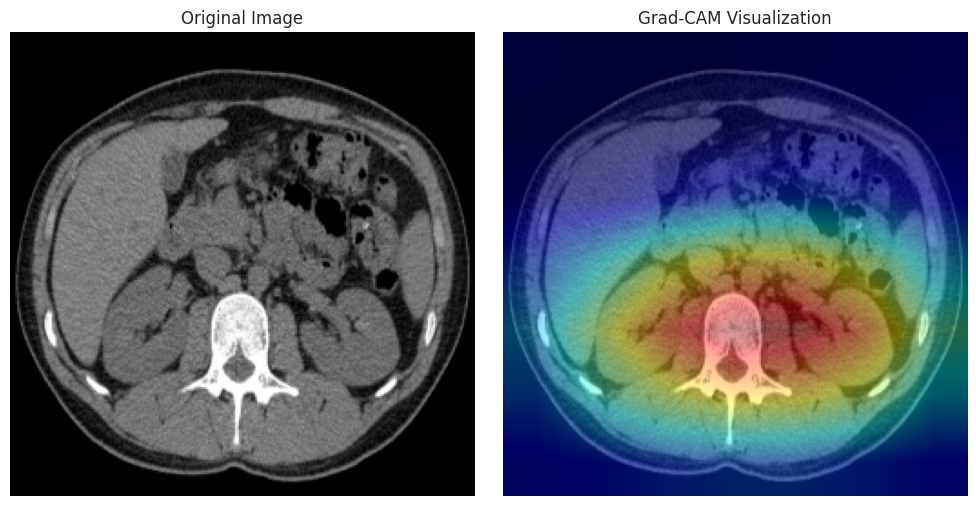

✅ Grad-CAM visualization displayed.


In [ ]:
# Resize and overlay the heatmap
# The heatmap needs to be resized to the original image dimensions
heatmap_resized = cv2.resize(heatmap, (img_np_original.shape[1], img_np_original.shape[0])) # Resize to original image size
heatmap_uint8 = np.uint8(255 * heatmap_resized) # Convert to uint8

# Apply a colormap
heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

# Superimpose the heatmap on the original image
# Convert original image to BGR if it's RGB for OpenCV
if img_np_original.shape[2] == 3:
    img_np_original_bgr = cv2.cvtColor(img_np_original, cv2.COLOR_RGB2BGR)
else:
     img_np_original_bgr = cv2.cvtColor(img_np_original, cv2.COLOR_GRAY2BGR)


# Blend the original image and the heatmap
superimposed_img = cv2.addWeighted(img_np_original_bgr, 0.6, heatmap_colored, 0.4, 0)

# Convert back to RGB for matplotlib display
superimposed_img_rgb = cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)

# Display the original image and the superimposed image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_np_original) # Display original image
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(superimposed_img_rgb) # Display superimposed image
plt.title("Grad-CAM Visualization")
plt.axis('off')

plt.tight_layout()
plt.show()

print("✅ Grad-CAM visualization displayed.")

✅ Binary mask created from heatmap.


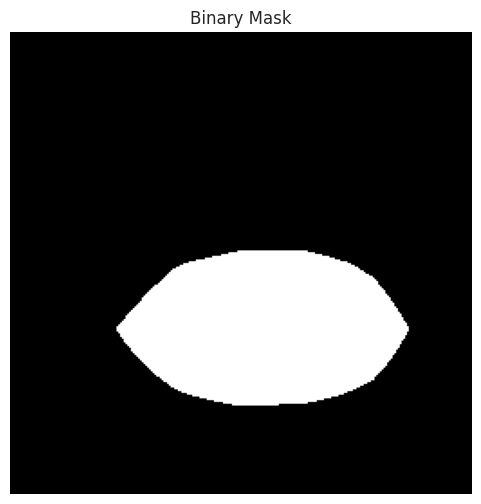

In [ ]:
# Ensure 'heatmap' and 'img_np_original' are accessible

# Resize the heatmap to the original image dimensions if not already done
# Note: The previous visualization step already resized it, but it's good practice
# to ensure we are working with the correct dimensions for mask creation if this cell is run independently.
heatmap_resized = cv2.resize(heatmap, (img_np_original.shape[1], img_np_original.shape[0]))

# Define a threshold value (you might need to adjust this based on your heatmaps)
# A common approach is to use a value between 0 and 1 for the normalized heatmap.
threshold_value = 0.6  # Example threshold, adjust as needed

# Apply thresholding to create a binary mask
# Pixels with intensity above the threshold will be set to 255 (white), others to 0 (black)
_, binary_mask = cv2.threshold(heatmap_resized, threshold_value, 255, cv2.THRESH_BINARY)

# Convert the binary mask to uint8 type
binary_mask = np.uint8(binary_mask)

print("✅ Binary mask created from heatmap.")

# Optional: Display the binary mask to check the result
plt.figure(figsize=(6, 6))
plt.imshow(binary_mask, cmap='gray')
plt.title("Binary Mask")
plt.axis('off')
plt.show()

In [ ]:
# Ensure 'binary_mask' and 'img_np_original' are accessible

# Find contours in the binary mask
# cv2.findContours modifies the input mask, so work on a copy
contours, _ = cv2.findContours(binary_mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# List to store bounding box coordinates
bounding_boxes = []

# Iterate through the found contours
for contour in contours:
    # Get the bounding box for the current contour
    x, y, w, h = cv2.boundingRect(contour)

    # Append the bounding box coordinates (x, y, width, height) to the list
    bounding_boxes.append((x, y, w, h))

print(f"✅ Found {len(bounding_boxes)} bounding boxes.")

# Optional: Print the bounding box coordinates
# for i, bbox in enumerate(bounding_boxes):
#     print(f"Bounding Box {i+1}: x={bbox[0]}, y={bbox[1]}, w={bbox[2]}, h={bbox[3]}")

✅ Found 1 bounding boxes.


✅ Bounding boxes drawn on the image.


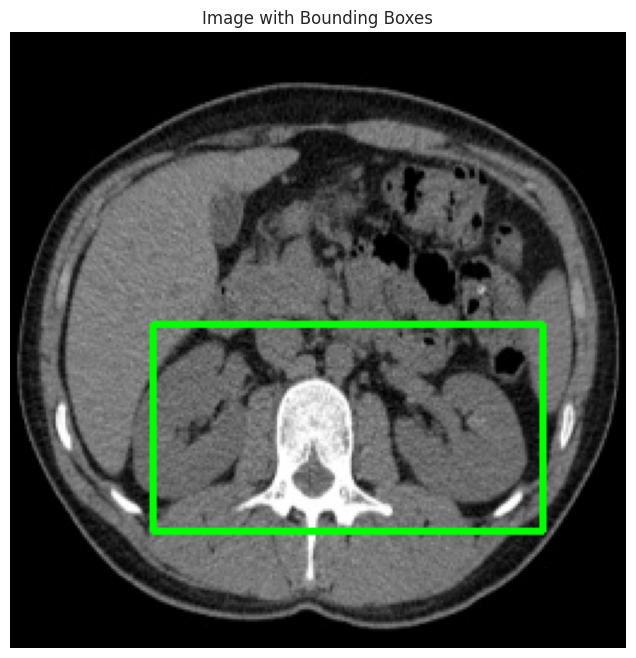

In [ ]:
# Ensure 'img_np_original' and 'bounding_boxes' are accessible

# Create a copy of the original image to draw on
image_with_boxes = np.copy(img_np_original)

# Define the color and thickness for the bounding boxes
box_color = (0, 255, 0)  # Green color (in BGR format as OpenCV uses BGR)
box_thickness = 2

# Iterate through the bounding boxes and draw each one on the image
for (x, y, w, h) in bounding_boxes:
    # Draw the rectangle (bounding box) on the image
    # cv2.rectangle(image, start_point, end_point, color, thickness)
    cv2.rectangle(image_with_boxes, (x, y), (x + w, y + h), box_color, box_thickness)

print(f"✅ Bounding boxes drawn on the image.")

# Display the original image with bounding boxes
plt.figure(figsize=(8, 8))
# Convert the image back to RGB for matplotlib display if it was in BGR (OpenCV's default)
# If img_np_original was already in RGB, no conversion is needed here.
# Since we copied from img_np_original (which was RGB), and cv2.rectangle works on it,
# the result should still be in RGB if the input was RGB.
plt.imshow(image_with_boxes)
plt.title("Image with Bounding Boxes")
plt.axis('off')
plt.show()